# Probabilistic Flood Mapping
## Uncertainty Quantification for Flood Modelling (UQ4FM) project, University of Edinburgh
### Nina Fischer, Adil Siripatana, Amy Wilson, Lindsay Beevers

This notebook demonstrates a case study for probabilistic flood mapping using surrogate modelling, applied to the town of Inverurie, Scotland, which sits at the confluence of the River Don and River Urie and has a long history of severe fluvial flooding. The most significant recent event occurred in January 2016. For details on the methods, we refer to:

Siripatana, A., Wilson, A. L., & Beevers, L. (2025). Uncertainty quantification for multi-input fluvial flood inundation using GPR- and PCE-based surrogates. *Water Resources Research*, 61, e2024WR039668. https://doi.org/10.1029/2024WR039668

## Overview

Traditional probabilistic flood modelling, such as Full Monte Carlo (FMC), requires running a hydraulic model hundreds or thousands of times to propagate input uncertainty through to inundation predictions. This is computationally prohibitive for high-resolution 2D models. This notebook implements a surrogate-based approach that replaces the expensive hydraulic model with a fast surrogate model, trained on a small set of model runs.

We focus on uncertainty in the **inflow boundary conditions**: the peak discharge at each upstream tributary and the timing lag between them. These inflow uncertainties have been shown to have a larger influence on flood inundation predictions than model parameter uncertainty.

The surrogate used here is **PCK (Polynomial Chaos Kriging)**, which combines a Polynomial Chaos Expansion (PCE) trend with a Gaussian Process Regression (GPR) residual. PCE provides a systematic way to approximate the model response surface using orthogonal polynomials, while the GPR component captures residual non-linear patterns and provides a built-in variance estimate. To handle the high dimensionality of the spatial flood maps, **POD (Proper Orthogonal Decomposition)** via SVD is first used to compress each map into a small number of dominant modes; a separate PCK model is then fitted to each modal coefficient.

## Workflow

**Step 0 — Calibrate the Flood Model**  
Calibrate the hydraulic model (here: LISFLOOD-FP) against observed flood events. Verify that the model accurately reproduces known inundation extents and water depths before proceeding.

---

### Stage 1: Inflow Analysis

**Step 1a — Analyse AMAX Data**  
Fit a GEV distribution to the Annual Maximum (AMAX) flow series for each tributary. Derive 95% bootstrap confidence bounds on peak inflows at the return period of interest. These bounds define the input uncertainty space.

**Step 1b — Analyse Lag**  
Characterise the timing difference between peak flows at each tributary pair from observed time series data. A Normal distribution is fitted to the empirical lag distribution to represent lag uncertainty.

---

### Stage 2: Surrogate Model Construction

**Step 2 — Generate Training Input Set**  
Use Sobol quasi-random sampling to generate space-filling combinations of peak inflows and lag.

**Step 3 — Construct Synthetic Hydrographs**  
Convert each sampled peak inflow into a full hydrograph by scaling a normalised unit hydrograph derived from a historical flood event. Apply the sampled lag by shifting the non-reference tributary hydrograph in time using cubic spline interpolation.

**Step 4 — Run the Hydraulic Model**  
Run LISFLOOD-FP for each training hydrograph. Extract the maximum inundation depth map for each simulation.

**Step 5 — Train the Surrogate Model**  
Compress flood maps using POD, then fit a PCK surrogate to map sampled inputs to POD coefficients.

**Step 6 — Validate the Surrogate**  
Evaluate surrogate performance on a held-out test set using spatial error metrics (R², MAE, Bias).

---

### Stage 3: Probabilistic Flood Mapping

**Step 7 — Sample the Inflow Space**  
Generate a large Monte Carlo ensemble of equally likely peak inflow realisations consistent with the target return period.

**Step 8 — Predict Inundation Maps**  
Pass the ensemble through the trained surrogate to obtain predicted maximum inundation maps with uncertainty estimates.

**Step 9 — Generate Probabilistic Flood Maps**  
Aggregate ensemble predictions to produce probability-of-inundation maps and depth percentile maps.

---
# CONFIGURATION
**Edit this cell and the cell below before running anything else.**  
All other cells read from these settings — no other paths or names need changing.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit this cell only
# ═══════════════════════════════════════════════════════════════════════════

# ── Site & analysis settings ────────────────────────────────────────────────
SITE_NAME     = "Inverurie"   # used in output folder names
RETURN_PERIOD = 30            # return period of interest (years)
N_SAMPLES     = 150           # number of training samples
SAMPLE_RULE   = "sobol"       # chaospy sampling rule
SAMPLE_SEED   = 23415           # random seed

# ── Tributaries ─────────────────────────────────────────────────────────────
# Add one dict per upstream boundary.
# Order must match the section order in your .bdy template file.
# Set "lag_reference": True on exactly ONE tributary — lags are measured from it.
TRIBUTARIES = [
    {
        "name":               "Don_at_Haughton",       # used in filenames/variables (no spaces)
        "label":              "Don at Haughton",        # used in plot titles
        "amax_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/Haughton_AMAX.xlsx",
        "amax_year_col":      "Year",                   # column name in AMAX file
        "amax_flow_col":      "Number",                 # column name in AMAX file
        "flow_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/SEPA_Inver_formatted/Haughton_15m_Q_All_formatted.csv",
        "flow_sep":           ";",                      # CSV separator
        "flow_timestamp_col": "Timestamp",
        "flow_value_col":     "Value",
        "bdy_section":        "upstream1",              # section name in .bdy file
        "lag_reference":      True,                     # lag measured FROM this tributary
    },
    {
        "name":               "Urie_at_Pitcaple",
        "label":              "Urie at Pitcaple",
        "amax_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/Pitcaple_Qmax_30yr.xlsx",
        "amax_year_col":      "Year",
        "amax_flow_col":      "Number",
        "flow_file":          "Z:/inverurie_data/Inverurie_emulator_Inputs/SEPA_Inver_formatted/Pitcaple_15m_Q_All_formatted.csv",
        "flow_sep":           ";",
        "flow_timestamp_col": "Timestamp",
        "flow_value_col":     "Value",
        "bdy_section":        "upstream2",
        "lag_reference":      False,
    },
    # To add a third tributary, copy the block above and append it here.
]

# ── Input files ─────────────────────────────────────────────────────────────
BDY_TEMPLATE = "Z:/inverurie_data/Inverurie_emulator_Inputs/Inverurie_8Jan2016_5m_normalized_new.bdy"

# ── Flood model grid ────────────────────────────────────────────────────────
NROWS = 1000
NCOLS = 900

# ── Return periods computed in GEV analysis ──────────────────────────────────
RETURN_PERIODS_GEV = [2, 5, 10, 20, 30, 50, 100, 120, 200]

# ── Output folders (all created automatically) ───────────────────────────────
OUTPUT_BASE     = f"./{SITE_NAME}_outputs"
FIGURES_DIR     = f"{OUTPUT_BASE}/figures"
GEV_DIR         = f"{OUTPUT_BASE}/gev_results"
SAMPLES_DIR     = f"{OUTPUT_BASE}/training_data/samples"
BDY_SCALED_DIR  = f"{OUTPUT_BASE}/training_data/bdy_scaled"   # scaled, pre-lag
BDY_SHIFTED_DIR = f"{OUTPUT_BASE}/training_data/bdy_shifted"  # scaled + lag applied
FLOOD_MAPS_DIR  = f"{OUTPUT_BASE}/flood_maps"                 # LISFLOOD output .max files go here
PREDICTIONS_DIR = f"{OUTPUT_BASE}/predictions"

---
# Software Setup
Run once to install/check all required packages.

In [2]:
# Python imports and output folder creation
import os, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chaospy as cp
import gstools
import joblib
import matplotlib.lines as mlines
from scipy.interpolate import splrep, splev
from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.stats import norm as scipy_norm
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from pyproj import Transformer

warnings.filterwarnings('ignore')

# Create all output directories
for d in [FIGURES_DIR, GEV_DIR, SAMPLES_DIR, BDY_SCALED_DIR, BDY_SHIFTED_DIR,
          FLOOD_MAPS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

# Derived config
N_TRIBUTARIES = len(TRIBUTARIES)
REF_IDX       = next(i for i, t in enumerate(TRIBUTARIES) if t["lag_reference"])
NON_REF_IDXS  = [i for i in range(N_TRIBUTARIES) if i != REF_IDX]
RET_IDX       = RETURN_PERIODS_GEV.index(RETURN_PERIOD)

print(f"Site:            {SITE_NAME}")
print(f"Tributaries:     {[t['label'] for t in TRIBUTARIES]}")
print(f"Lag reference:   {TRIBUTARIES[REF_IDX]['label']}")
print(f"Return period:   1-in-{RETURN_PERIOD} years")
print(f"Training samples: {N_SAMPLES}")
print(f"Output base:     {OUTPUT_BASE}")

Site:            Inverurie
Tributaries:     ['Don at Haughton', 'Urie at Pitcaple']
Lag reference:   Don at Haughton
Return period:   1-in-30 years
Training samples: 150
Output base:     ./Inverurie_outputs


In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
# Install any missing R packages
packages <- c("readxl", "ggplot2", "extRemes", "gridExtra")
for (pkg in packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    cat("Installing:", pkg, "\n")
    install.packages(pkg)
  } else {
    cat("Already installed:", pkg, "\n")
  }
}

Already installed: readxl 
Already installed: ggplot2 
Already installed: extRemes 
Already installed: gridExtra 


---
# Stage 1: Inflow Analysis
## Step 1a: GEV Analysis of AMAX Data

The **Generalised Extreme Value (GEV)** distribution is fitted to the Annual Maximum (AMAX) flow series for each tributary using maximum likelihood estimation. The GEV family encompasses the Gumbel, Fréchet, and Weibull distributions as special cases, making it a flexible and well-established choice for flood frequency analysis.

95% confidence intervals on the GEV quantiles are derived using a **bootstrap method** (1000 resamples), as implemented in the `extRemes` R package. The lower and upper bounds at the return period of interest define the range of plausible peak inflows, which are used as the bounds of the Uniform input distributions in the subsequent sampling stage.

In [5]:
# Build R config strings from Python TRIBUTARIES list
# These are injected into R via rpy2 before running the GEV cell

import rpy2.robjects as ro

# Build R config strings from Python TRIBUTARIES list
import rpy2.robjects as ro

# Build R file_configs list string — no trailing comma after last item
r_file_configs_str = "file_configs <- list(\n"
for i, t in enumerate(TRIBUTARIES):
    path = t['amax_file'].replace('\\', '/')
    entry = (
        f"  list(path='{path}', label=\"{t['label']}\", "
        f"year_col=\"{t['amax_year_col']}\", flow_col=\"{t['amax_flow_col']}\")"
    )
    # Add comma after every entry except the last
    if i < len(TRIBUTARIES) - 1:
        entry += ","
    r_file_configs_str += entry + "\n"
r_file_configs_str += ")"

# Inject variables into R
ro.r(r_file_configs_str)
ro.r(f"return_periods <- c({', '.join(str(x) for x in RETURN_PERIODS_GEV)})")
ro.r(f"target_rp <- {RETURN_PERIOD}")
ro.r(f"output_dir <- '{GEV_DIR.replace(chr(92), '/')}/'")
ro.r(f"figures_dir <- '{FIGURES_DIR.replace(chr(92), '/')}/'")
ro.r(f"n_tribs <- {N_TRIBUTARIES}")

print("R config injected successfully")

R config injected successfully


[Don at Haughton] RP 10-yr  GEV: 222.76  Lower: 175.14  Upper: 273.50
[Don at Haughton] RP 30-yr  GEV: 291.61  Lower: 208.23  Upper: 427.90
[Don at Haughton] RP 100-yr  GEV: 376.22  Lower: 228.54  Upper: 727.98
[Don at Haughton] Results saved to: ./Inverurie_outputs/gev_results/gev_results_Don_at_Haughton.csv

[Urie at Pitcaple] RP 10-yr  GEV: 33.53  Lower: 26.90  Upper: 40.62
[Urie at Pitcaple] RP 30-yr  GEV: 42.06  Lower: 31.30  Upper: 54.52
[Urie at Pitcaple] RP 100-yr  GEV: 50.99  Lower: 34.33  Upper: 77.48
[Urie at Pitcaple] Results saved to: ./Inverurie_outputs/gev_results/gev_results_Urie_at_Pitcaple.csv



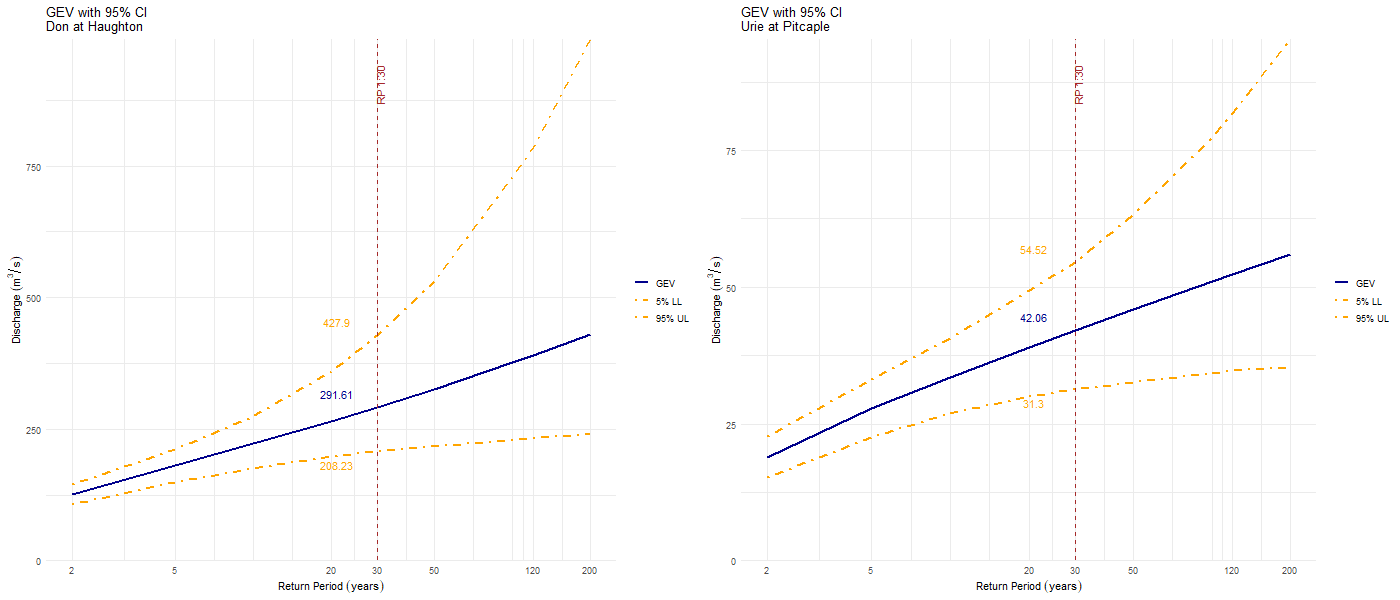

In [6]:
%%R -w 1400 -h 600
suppressWarnings(suppressPackageStartupMessages({
  library(readxl); library(ggplot2); library(extRemes); library(gridExtra)
}))

set.seed(123)

process_file <- function(cfg) {
  data   <- read_excel(cfg$path)
  Qmax   <- data.frame(Year = data[[cfg$year_col]], Q = data[[cfg$flow_col]])
  fit    <- fevd(Qmax$Q, type = "GEV")
  quants <- sapply(return_periods, function(rp) return.level(fit, return.period = rp))

  invisible(capture.output(
    ci_res <- ci(fit, type = "return.level", return.period = return_periods,
                 method = "boot", nboot = 1000)
  ))
  lower <- ci_res[, "2.5%"]
  upper <- ci_res[, "97.5%"]

  # Print key values
  for (rp in c(10, target_rp, 100)) {
    idx <- which(return_periods == rp)
    cat(sprintf("[%s] RP %d-yr  GEV: %.2f  Lower: %.2f  Upper: %.2f\n",
                cfg$label, rp, quants[idx], lower[idx], upper[idx]))
  }

  # Save results CSV
  out_csv <- paste0(output_dir, "gev_results_", gsub(" ", "_", cfg$label), ".csv")
  write.csv(data.frame(ReturnPeriod=return_periods, GEV_Quantile=quants,
                        Lower_Limit=lower, Upper_Limit=upper),
            file=out_csv, row.names=FALSE)
  cat(sprintf("[%s] Results saved to: %s\n\n", cfg$label, out_csv))

  # Store in global env for export to Python
  suffix <- gsub(" ", "_", cfg$label)
  assign(paste0("gev_lower_", suffix), lower, envir=.GlobalEnv)
  assign(paste0("gev_upper_", suffix), upper, envir=.GlobalEnv)

  # Build plot
  plot_data <- data.frame(
    ReturnPeriod = rep(return_periods, 3),
    Magnitude    = c(quants, lower, upper),
    Type         = rep(c("GEV", "Lower Limit", "Upper Limit"), each=length(return_periods))
  )
  y_max   <- max(plot_data$Magnitude)
  idx_rp  <- which(return_periods == target_rp)
  v <- list(gev=quants[idx_rp], lower=lower[idx_rp], upper=upper[idx_rp])

  p <- ggplot(plot_data, aes(x=ReturnPeriod, y=Magnitude, color=Type, linetype=Type)) +
    geom_line(linewidth=1) +
    scale_color_manual(values=c("darkblue","orange","orange"), labels=c("GEV","5% LL","95% UL")) +
    scale_linetype_manual(values=c("solid","dotdash","dotdash"), labels=c("GEV","5% LL","95% UL")) +
    labs(x=expression(Return~Period~(years)), y=expression(Discharge~(m^3/s)),
         title=paste0("GEV with 95% CI\n", cfg$label)) +
    theme_minimal() +
    scale_x_continuous(trans='log10', breaks=return_periods,
                       labels=ifelse(return_periods %in% c(10,100),"",as.character(return_periods))) +
    scale_y_continuous(expand=c(0,0), limits=c(0,NA)) +
    theme(legend.title=element_blank()) +
    geom_vline(xintercept=target_rp, linetype="dashed", color="brown") +
    annotate("text", x=target_rp*1.15, y=y_max*0.95,
             label=paste0("RP 1:",target_rp), vjust=-1, color="brown", angle=90, hjust=1) +
    annotate("text", x=target_rp*0.7, y=v$gev,   label=round(v$gev,2),   vjust=-1, color="darkblue") +
    annotate("text", x=target_rp*0.7, y=v$lower, label=round(v$lower,2), vjust=2,  color="orange") +
    annotate("text", x=target_rp*0.7, y=v$upper, label=round(v$upper,2), vjust=-1, color="orange")
  return(p)
}

plots <- lapply(file_configs, process_file)
grid.arrange(grobs=plots, ncol=length(plots))

In [7]:
# Load GEV bounds into Python — from R memory if available, otherwise from saved CSV
gev_bounds = {}

for t in TRIBUTARIES:
    safe = t['label'].replace(' ', '_')
    try:
        import rpy2.robjects as ro
        lower = float(list(ro.r(f"gev_lower_{safe}"))[RET_IDX])
        upper = float(list(ro.r(f"gev_upper_{safe}"))[RET_IDX])
        print(f"[{t['label']}] Using in-memory GEV bounds")
    except Exception:
        csv_path = os.path.join(GEV_DIR, f"gev_results_{safe}.csv")
        row = pd.read_csv(csv_path)
        row = row[row['ReturnPeriod'] == RETURN_PERIOD].iloc[0]
        lower, upper = row['Lower_Limit'], row['Upper_Limit']
        print(f"[{t['label']}] Loaded GEV bounds from CSV")

    gev_bounds[t['name']] = {'lower': lower, 'upper': upper}
    print(f"  {RETURN_PERIOD}-yr bounds: {lower:.2f} – {upper:.2f} m³/s")

[Don at Haughton] Using in-memory GEV bounds
  30-yr bounds: 208.23 – 427.90 m³/s
[Urie at Pitcaple] Using in-memory GEV bounds
  30-yr bounds: 31.30 – 54.52 m³/s


## Step 1b: Lag Analysis

When two tributaries contribute to flooding at a confluence, the **relative timing of their peak flows** can significantly affect the severity of inundation downstream. A scenario where both tributaries peak simultaneously will generally produce higher water levels than one where the peaks are offset in time.

Here, peaks are detected in the observed 15-minute flow time series for each tributary using a prominence-filtered peak-finding algorithm. For each peak in the reference tributary, the nearest peak in the comparison tributary is found, and the time difference (lag) is recorded. Only lags within a physically plausible window (±12 hours) are retained.

A **Normal distribution** is fitted to the resulting empirical lag distribution. The mean and standard deviation of this distribution are used to define the lag input in the joint probability model. 

[Urie at Pitcaple] Lag  mean: -263.6 min  std: 290.5 min


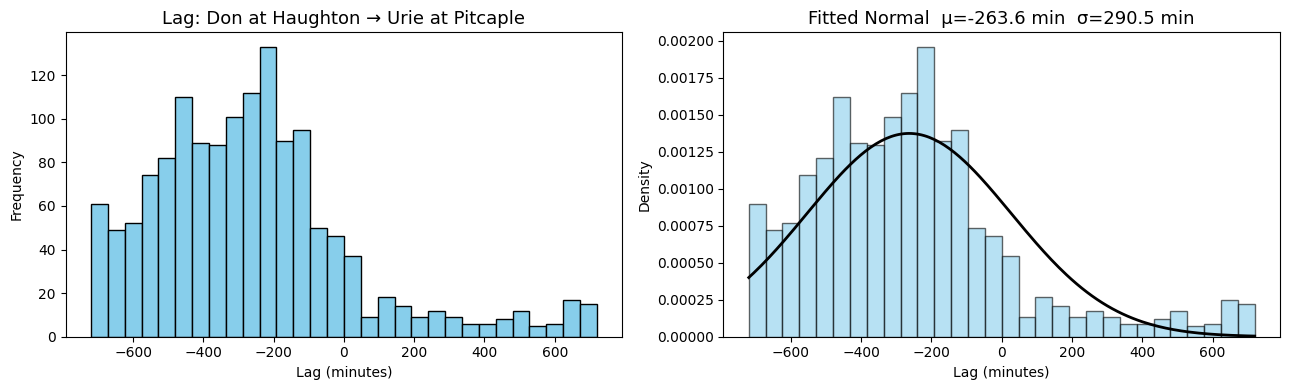

In [8]:
# Lag analysis — generalised for any number of tributaries
lag_stats = {}  # {trib_name: (mu_seconds, std_seconds)}

# Load reference tributary flow
ref = TRIBUTARIES[REF_IDX]
ref_df = pd.read_csv(ref['flow_file'], sep=ref['flow_sep'])
ref_df[ref['flow_timestamp_col']] = pd.to_datetime(ref_df[ref['flow_timestamp_col']])
ref_peaks, _ = find_peaks(ref_df[ref['flow_value_col']], height=0, prominence=0.5)
ref_times = ref_df[ref['flow_timestamp_col']].iloc[ref_peaks].reset_index(drop=True)

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    df = pd.read_csv(t['flow_file'], sep=t['flow_sep'])
    df[t['flow_timestamp_col']] = pd.to_datetime(df[t['flow_timestamp_col']])
    peaks, _ = find_peaks(df[t['flow_value_col']], height=0, prominence=0.5)
    peak_times = df[t['flow_timestamp_col']].iloc[peaks].reset_index(drop=True)

    lags_min = []
    for h_time in ref_times:
        diffs = peak_times - h_time
        closest = diffs[np.abs(diffs).argmin()].total_seconds() / 60
        if -720 <= closest <= 720:
            lags_min.append(closest)

    mu_min, std_min = scipy_norm.fit(lags_min)
    lag_stats[t['name']] = (mu_min * 60, std_min * 60)  # store in seconds

    print(f"[{t['label']}] Lag  mean: {mu_min:.1f} min  std: {std_min:.1f} min")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(lags_min, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title(f"Lag: {ref['label']} → {t['label']}", fontsize=13)
    axes[0].set_xlabel('Lag (minutes)')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(lags_min, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    x_fit = np.linspace(min(lags_min), max(lags_min), 200)
    axes[1].plot(x_fit, scipy_norm.pdf(x_fit, mu_min, std_min), 'k', linewidth=2)
    axes[1].set_title(f"Fitted Normal  μ={mu_min:.1f} min  σ={std_min:.1f} min", fontsize=13)
    axes[1].set_xlabel('Lag (minutes)')
    axes[1].set_ylabel('Density')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"lag_distribution_{t['name']}.png"), dpi=150)
    plt.show()

---
# Stage 2: Surrogate Model Construction
## Step 2: Generate Training Input Set (Sobol Sampling)

We construct a joint probability distribution overl all uncertain inputs:
- One **Uniform** distribution per tributary, with bounds taken from the GEV confidence interval at the target return period.
- One **Normal** distribution per non-reference tributary lag, parameterised by the mean and standard deviation fitted in Step 1b.

**Sobol quasi-random sequences** are used to generate the training input set. 

Joint distribution:
  Don at Haughton: Uniform(208.23, 427.90) m³/s
  Urie at Pitcaple: Uniform(31.30, 54.52) m³/s
  Lag (Urie at Pitcaple): Normal(μ=-15816s, σ=17430s)

Saved 3 sample arrays to: ./Inverurie_outputs/training_data/samples


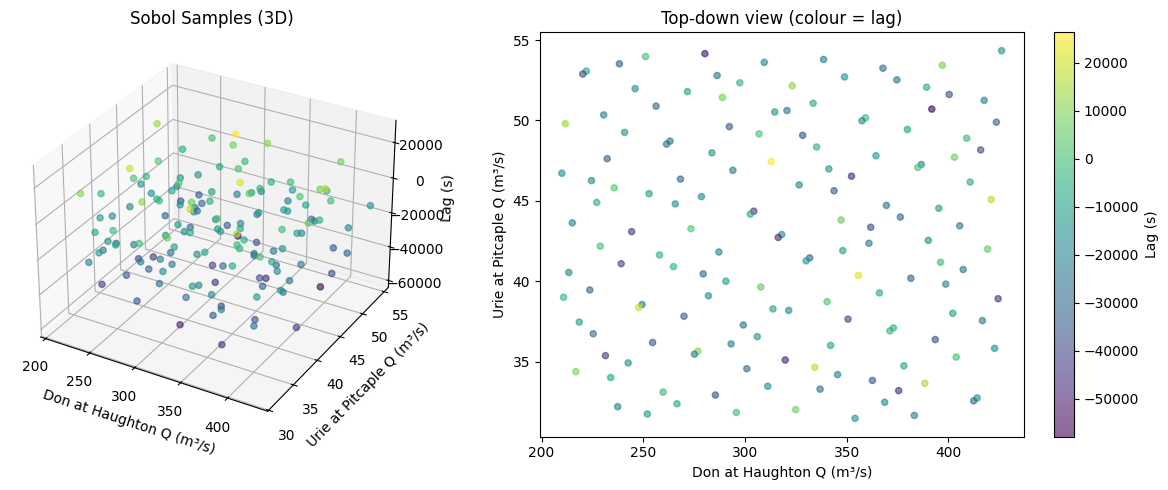

In [9]:
# Build joint distribution and generate Sobol samples
distributions = []
dist_labels   = []

print("Joint distribution:")
for t in TRIBUTARIES:
    b = gev_bounds[t['name']]
    distributions.append(cp.Uniform(b['lower'], b['upper']))
    dist_labels.append(t['name'])
    print(f"  {t['label']}: Uniform({b['lower']:.2f}, {b['upper']:.2f}) m³/s")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    mu_s, std_s = lag_stats[t['name']]
    distributions.append(cp.Normal(mu_s, std_s))
    dist_labels.append(f"lag_{t['name']}")
    print(f"  Lag ({t['label']}): Normal(μ={mu_s:.0f}s, σ={std_s:.0f}s)")

joint         = cp.J(*distributions)
sobol_samples = joint.sample(N_SAMPLES, rule=SAMPLE_RULE)

# Store in a dict keyed by label
nodes = {dist_labels[i]: sobol_samples[i] for i in range(len(dist_labels))}

# Save each dimension to CSV
for label, arr in nodes.items():
    out_path = os.path.join(SAMPLES_DIR, f"nodes_{label}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    pd.DataFrame(arr).to_csv(out_path, index=False, header=False)

print(f"\nSaved {len(nodes)} sample arrays to: {SAMPLES_DIR}")

# 3D scatter (first 2 flows + first lag)
if len(distributions) >= 3:
    x, y, z = sobol_samples[0], sobol_samples[1], sobol_samples[2]
    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x, y, z, c=z, cmap='viridis', alpha=0.6, s=20)
    ax1.set_xlabel(f"{TRIBUTARIES[0]['label']} Q (m³/s)")
    ax1.set_ylabel(f"{TRIBUTARIES[1]['label']} Q (m³/s)")
    ax1.set_zlabel('Lag (s)')
    ax1.set_title('Sobol Samples (3D)')
    ax2 = fig.add_subplot(122)
    sc = ax2.scatter(x, y, c=z, cmap='viridis', alpha=0.6, s=20)
    ax2.set_xlabel(f"{TRIBUTARIES[0]['label']} Q (m³/s)")
    ax2.set_ylabel(f"{TRIBUTARIES[1]['label']} Q (m³/s)")
    ax2.set_title('Top-down view (colour = lag)')
    plt.colorbar(sc, ax=ax2, label='Lag (s)')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"sobol_samples_{RETURN_PERIOD}yr.png"), dpi=150)
    plt.show()

## Step 3: Construct Synthetic Hydrographs

### Step 3a: Scale normalised hydrograph
We derived a single representative hydrograph shape from a historical flood event (here: the January 2016 event) and normalised it so that its peak equals 1. Each sampled peak inflow value is then used as a scaling factor, producing a hydrograph with the correct peak magnitude while preserving the observed shape of the flood wave. The scaling is applied to each upstream boundary section independently to each stream in the LISFLOOD-FP `.bdy` input file.



In [10]:
# Load flow sample arrays — from memory if available, else from CSV
flow_nodes = {}
for t in TRIBUTARIES:
    try:
        flow_nodes[t['name']] = nodes[t['name']]
        print(f"[{t['label']}] Using in-memory samples")
    except (NameError, KeyError):
        csv_path = os.path.join(SAMPLES_DIR, f"nodes_{t['name']}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
        flow_nodes[t['name']] = pd.read_csv(csv_path, header=None)[0].values
        print(f"[{t['label']}] Loaded from CSV: {csv_path}")

# Load lag sample arrays
lag_nodes = {}
for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    lag_key = f"lag_{t['name']}"
    try:
        lag_nodes[t['name']] = nodes[lag_key]
        print(f"[lag {t['label']}] Using in-memory samples")
    except (NameError, KeyError):
        csv_path = os.path.join(SAMPLES_DIR, f"nodes_{lag_key}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
        lag_nodes[t['name']] = pd.read_csv(csv_path, header=None)[0].values
        print(f"[lag {t['label']}] Loaded from CSV: {csv_path}")

[Don at Haughton] Using in-memory samples
[Urie at Pitcaple] Using in-memory samples
[lag Urie at Pitcaple] Using in-memory samples


In [13]:
# ── Step 3a: Scale hydrographs ──────────────────────────────────────────────
def modify_bdy_file(input_file, output_file, factors):
    """Scale .bdy file sections by their respective factors.
    factors: dict of {bdy_section_name: scale_factor}"""
    with open(input_file, 'r') as f:
        lines = f.readlines()
    current_section = None
    with open(output_file, 'w') as f:
        for line in lines:
            matched = next((t['bdy_section'] for t in TRIBUTARIES
                            if line.strip().startswith(t['bdy_section'])), None)
            if matched:
                current_section = matched
                f.write(line)
                continue
            if current_section in factors:
                parts = line.split()
                if len(parts) >= 2 and parts[1] != 'seconds':
                    try:
                        value = float(parts[0]) * factors[current_section] / 5
                        f.write(f"{value}\t{chr(9).join(parts[1:])}\n")
                        continue
                    except ValueError:
                        pass
            f.write(line)

os.makedirs(BDY_SCALED_DIR, exist_ok=True)
n_files = len(next(iter(flow_nodes.values())))

for i in range(n_files):
    factors = {t['bdy_section']: flow_nodes[t['name']][i] for t in TRIBUTARIES}
    out_path = os.path.join(BDY_SCALED_DIR, f"sobol_{i+1}.bdy")
    modify_bdy_file(BDY_TEMPLATE, out_path, factors)

print(f"Created {n_files} scaled .bdy files in: {BDY_SCALED_DIR}")

BDY_TEMPLATE exists: True
BDY_TEMPLATE path:   Z:/inverurie_data/Inverurie_emulator_Inputs/Inverurie_8Jan2016_5m_normalized_new.bdy
BDY_SCALED_DIR:      ./Inverurie_outputs/training_data/bdy_scaled
flow_nodes keys:     ['Don_at_Haughton', 'Urie_at_Pitcaple']
sample lengths:      [150, 150]
Created 150 scaled .bdy files in: ./Inverurie_outputs/training_data/bdy_scaled


### Step 3b: Apply lag
The sampled lag is applied to shift the non-reference tributary hydrograph in time, using cubic spline interpolation. The sampled lag is applied to the non-reference tributary by shifting its hydrograph in time. Cubic spline interpolation is used to resample the shifted hydrograph onto the original time steps.

In [14]:
# ── Step 3b: Apply lag shift ────────────────────────────────────────────────

def find_section_start(lines, section_name):
    for i, line in enumerate(lines):
        if section_name in line.strip():
            return i
    raise ValueError(f"Section '{section_name}' not found in file.")

def apply_lag_shift(input_file, output_file, shift_seconds, section_name):
    """Shift the specified .bdy section in time by shift_seconds using cubic spline."""
    with open(input_file, 'r') as f:
        lines = f.readlines()

    start_idx = find_section_start(lines, section_name) + 2
    time, flow = [], []
    for line in lines[start_idx:]:
        if not line.strip() or 'seconds' in line:
            continue
        try:
            fv, tv = map(float, line.split())
            flow.append(fv)
            time.append(tv)
        except ValueError:
            continue

    time = np.array(time)
    flow = np.array(flow)
    spline       = splrep(time, flow)
    shifted_flow = splev(time - shift_seconds, spline)
    shifted_flow[0] = 0
    shifted_flow[shifted_flow < 0] = 0

    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'w') as f:
        for line in lines[:start_idx]:
            f.write(line)
        for t_val, fl in zip(time, shifted_flow):
            f.write(f"{fl:.9f}\t{t_val}\n")
        f.writelines(lines[start_idx + len(shifted_flow):])

# Apply lag shifts for each non-reference tributary
bdy_files = sorted([f for f in os.listdir(BDY_SCALED_DIR) if f.endswith('.bdy')])
print(f"Found {len(bdy_files)} scaled .bdy files")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    shift_values = lag_nodes[t['name']]
    section      = t['bdy_section']
    print(f"\nApplying lag shifts for: {t['label']} (section: {section})")

    for i, bdy_file in enumerate(bdy_files):
        if i >= len(shift_values):
            print(f"  No lag value for {bdy_file}, skipping")
            continue
        in_path  = os.path.join(BDY_SCALED_DIR, bdy_file)
        out_path = os.path.join(BDY_SHIFTED_DIR, bdy_file)
        apply_lag_shift(in_path, out_path, shift_values[i], section)

print(f"\nDone. Final hydrograph files saved to: {BDY_SHIFTED_DIR}")

Found 150 scaled .bdy files

Applying lag shifts for: Urie at Pitcaple (section: upstream2)

Done. Final hydrograph files saved to: ./Inverurie_outputs/training_data/bdy_shifted


In [15]:
# code to generate a hydrograph for the deterministic case
# ── Single hydrograph: fixed peak inflows, zero lag ──────────────────────────
factors = {
    "upstream1": 281.74,   # here: Don. The numbers here come from JBA: http://www.inveruriefloodstudy.com/media/reports/Hydrology.pdf
    "upstream2": 88.07,    # here: Urie
}

out_path = os.path.join(BDY_SCALED_DIR, "single_Don281_Urie88_lag0.bdy")
modify_bdy_file(BDY_TEMPLATE, out_path, factors)
print(f"Created: {out_path}")

Created: ./Inverurie_outputs/training_data/bdy_scaled\single_Don281_Urie88_lag0.bdy


---
## Step 4: Run the Hydraulic Model

Run LISFLOOD-FP for each `.bdy` file in `bdy_shifted/`. LISFLOOD-FP is a 2D hydrodynamic model that solves the shallow water equations on a regular grid. It is widely used for flood inundation modelling due to its computational efficiency and ability to simulate sub-critical and super-critical flow regimes.

Each simulation produces a `.max` file containing the maximum inundation depth at every grid cell over the full simulation period. These maximum depth maps are the training outputs for the surrogate model.

Place all `.max` output files into the folder specified by `FLOOD_MAPS_DIR` before proceeding to Step 5.

Expected output filenames: `test_Res_1.max`, `test_Res_2.max`, ... `test_Res_N.max`

---
## Step 5: Train the Surrogate Model

### Dimensionality Reduction via POD
Maximum inundation depth maps have one value per grid cell (here: 612 × 952 = ~582,000 values), making it impractical to fit a separate surrogate to each cell directly. Instead, **Proper Orthogonal Decomposition (POD)** of the snapshot matrix is used to identify the dominant spatial patterns (modes) in the training data. A small number of modes (typically 10) captures the vast majority of the variance in the ensemble, compressing the output from ~582,000 dimensions to just 10 scalar coefficients per simulation.

### PCK Surrogate
A **Polynomial Chaos Kriging (PCK)** model is fitted independently to each of the 10 POD coefficients. PCK combines:
- A **PCE (Polynomial Chaos Expansion)** trend of degree 2, which uses orthogonal polynomials matched to the input distributions to capture the dominant response surface.
- A **GPR (Gaussian Process Regression)** residual using a Gaussian covariance kernel, which captures non-linear departures from the polynomial trend and provides a variance estimate at any new input point.

Inputs are normalised to zero mean and unit variance before fitting to ensure numerical stability of the Kriging system.

In [16]:
# Helper: read a LISFLOOD .max file
def process_flood_file(file_path, nrows=NROWS, ncols=NCOLS):
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        if len(lines) <= 6:
            print(f"File {file_path} has too few lines. Skipping.")
            return None
        flood_data = []
        for line in lines[6:]:
            try:
                flood_data.extend([float(v) for v in line.split()])
            except ValueError:
                print(f"Malformed line in {file_path}. Skipping file.")
                return None
        if len(flood_data) != nrows * ncols:
            print(f"Unexpected data size in {file_path}. Skipping.")
            return None
        return np.array(flood_data).reshape((nrows, ncols))
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

Loaded flow nodes: Don at Haughton  (150 samples)
Loaded flow nodes: Urie at Pitcaple  (150 samples)
Loaded lag nodes:  Urie at Pitcaple  (150 samples)

Inputs matrix shape: (3, 150)  (3 dims × 150 samples)


Loading flood maps: 100%|██████████████████| 150/150 [00:52<00:00,  2.88it/s]


Snapshot matrix shape: (900000, 150)  (pixels × snapshots)

Variance explained by 6 POD modes: 99.99%


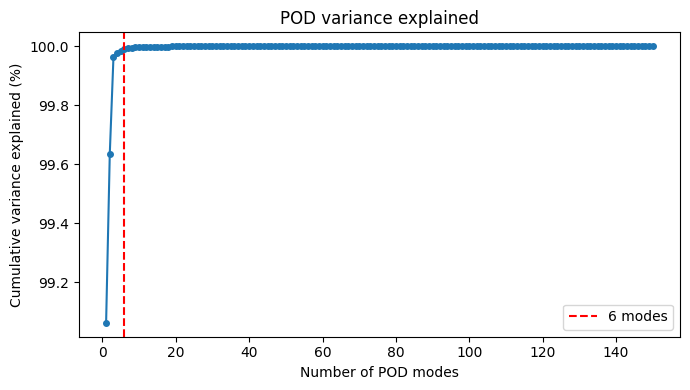

In [21]:
# ── Step 5: Load Training Data (we assume from csv as flood model takes a while to run) ──────────────────────────────────────────────
N_SAMPLES = 150 # change!!
# Set these paths manually after LISFLOOD has finished running
FLOOD_MAPS_DIR  = "C:/Users/nfische2/Documents/case_study/Inverurie_outputs/flood_maps"  # folder with .max files
NODES_LIST_DIR  = "Z:/inverurie_data/Inverurie_emulator_Inputs"   # folder with nodes CSVs — leave as SAMPLES_DIR or override
# NODES_LIST_DIR  = SAMPLES_DIR   # folder with nodes CSVs — leave as SAMPLES_DIR or override

# Load input sample arrays from CSV
all_arrays = []
for t in TRIBUTARIES:
    csv_path = os.path.join(NODES_LIST_DIR, f"nodes_{t['name']}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    arr = pd.read_csv(csv_path, header=None)[0].values
    all_arrays.append(arr)
    print(f"Loaded flow nodes: {t['label']}  ({len(arr)} samples)")

for idx in NON_REF_IDXS:
    t = TRIBUTARIES[idx]
    lag_key  = f"lag_{t['name']}"
    csv_path = os.path.join(NODES_LIST_DIR, f"nodes_{lag_key}_{RETURN_PERIOD}yr_{N_SAMPLES}.csv")
    arr = pd.read_csv(csv_path, header=None)[0].values
    all_arrays.append(arr)
    print(f"Loaded lag nodes:  {t['label']}  ({len(arr)} samples)")

inputs_matrix = np.vstack(all_arrays)[:, :N_SAMPLES]
print(f"\nInputs matrix shape: {inputs_matrix.shape}  ({inputs_matrix.shape[0]} dims × {inputs_matrix.shape[1]} samples)")

# Load flood map snapshots from LISFLOOD output folder
snapshots = []
missing   = []

for i in tqdm(range(1, N_SAMPLES + 1), desc="Loading flood maps"):
    file_path = os.path.join(FLOOD_MAPS_DIR, f"test_Res_{i}.max")
    flood_map = process_flood_file(file_path)
    if flood_map is not None:
        snapshots.append(flood_map.flatten())
    else:
        missing.append(i)

if missing:
    print(f"\nWarning: {len(missing)} files missing or unreadable: {missing}")

snapshot_matrix = np.array(snapshots).T
print(f"Snapshot matrix shape: {snapshot_matrix.shape}  (pixels × snapshots)")

# POD via SVD
N_POD_MODES = 6
U, S, Vt = svd(snapshot_matrix, full_matrices=False)
pod_coefficients = np.dot(U.T, snapshot_matrix)
pod_coeff_trunc  = pod_coefficients[:N_POD_MODES, :].T

explained = np.cumsum(S**2) / np.sum(S**2)
print(f"\nVariance explained by {N_POD_MODES} POD modes: {explained[N_POD_MODES-1]*100:.2f}%")

# Plot explained variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(S)+1), np.cumsum(S**2)/np.sum(S**2)*100, marker='o', markersize=4)
plt.axvline(N_POD_MODES, color='red', linestyle='--', label=f'{N_POD_MODES} modes')
plt.xlabel('Number of POD modes')
plt.ylabel('Cumulative variance explained (%)')
plt.title('POD variance explained')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pod_variance_explained.png"), dpi=150)
plt.show()

In [22]:
# Fit PCK surrogate
n_dims = inputs_matrix.shape[0]

# Normalise inputs
scaler_X    = StandardScaler()
X_train_norm = scaler_X.fit_transform(inputs_matrix.T)  # (snapshots, n_dims)

# Normalise POD outputs
scalers_Y    = []
Y_train_norm = np.zeros_like(pod_coeff_trunc)
for j in range(pod_coeff_trunc.shape[1]):
    sc = StandardScaler()
    Y_train_norm[:, j] = sc.fit_transform(pod_coeff_trunc[:, j].reshape(-1, 1)).ravel()
    scalers_Y.append(sc)

# PCE polynomial basis
dists_norm  = [cp.Normal(0, 1) for _ in range(n_dims)]
joint_norm  = cp.J(*dists_norm)
expansion   = cp.generate_expansion(2, joint_norm)

# Fit one Kriging model per POD mode
model_gst = gstools.Gaussian(dim=n_dims, var=1)
pck_models = []
for i in range(Y_train_norm.shape[1]):
    pck = gstools.krige.Universal(
        model_gst,
        cond_pos=X_train_norm.T,
        cond_val=Y_train_norm[:, i],
        drift_functions=list(expansion)
    )
    pck_models.append(pck)
    print(f"  Fitted PCK model for POD mode {i+1}/{N_POD_MODES}")

print("\nSurrogate training complete.")

joblib.dump({
    'pck_models':    pck_models,
    'scaler_X':      scaler_X,
    'scalers_Y':     scalers_Y,
    'U':             U,
    'S':             S,
    'N_POD_MODES':   N_POD_MODES,
    'NROWS':         NROWS,
    'NCOLS':         NCOLS,
    'X_train_norm':  X_train_norm,
    'Y_train_norm':  Y_train_norm,
    'inputs_matrix': inputs_matrix,
}, os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib'))

print(f"Surrogate saved to: {os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib')}")

  Fitted PCK model for POD mode 1/6
  Fitted PCK model for POD mode 2/6
  Fitted PCK model for POD mode 3/6
  Fitted PCK model for POD mode 4/6
  Fitted PCK model for POD mode 5/6
  Fitted PCK model for POD mode 6/6

Surrogate training complete.
Surrogate saved to: ./Inverurie_outputs\trained_surrogate.joblib


---
## Step 6: Validate the Surrogate
*(Optional but recommended)*  
Run LISFLOOD-FP using a leave one out k-fold validation approach and compare surrogate predictions against the full model outputs.

  Fold 1/10 complete  (train=135, test=15)
  Fold 2/10 complete  (train=135, test=15)
  Fold 3/10 complete  (train=135, test=15)
  Fold 4/10 complete  (train=135, test=15)
  Fold 5/10 complete  (train=135, test=15)
  Fold 6/10 complete  (train=135, test=15)
  Fold 7/10 complete  (train=135, test=15)
  Fold 8/10 complete  (train=135, test=15)
  Fold 9/10 complete  (train=135, test=15)
  Fold 10/10 complete  (train=135, test=15)


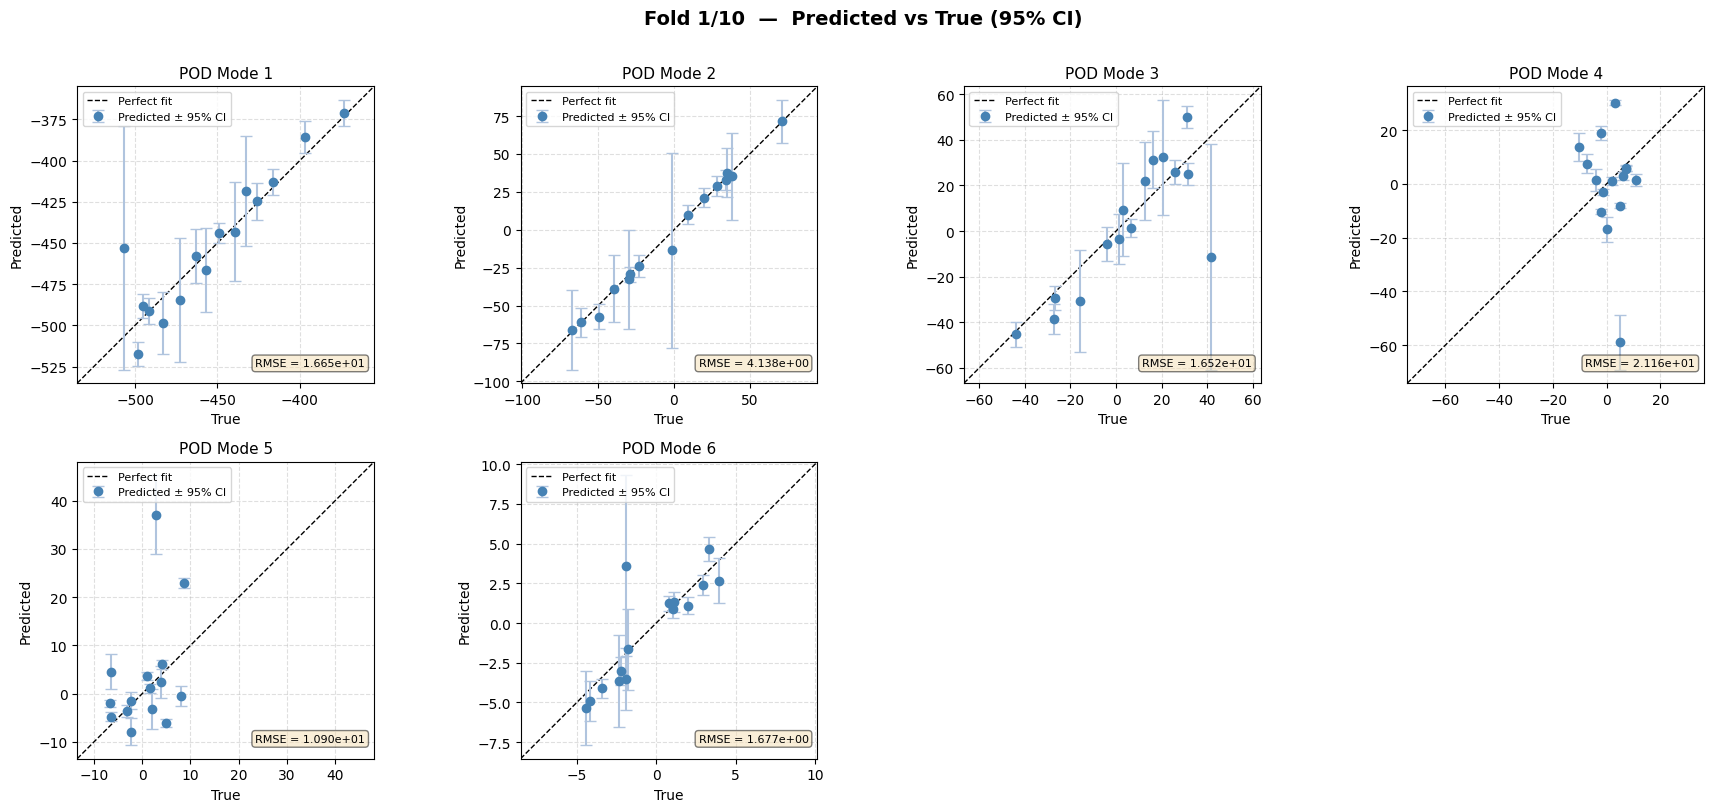

  Saved plot for fold 1


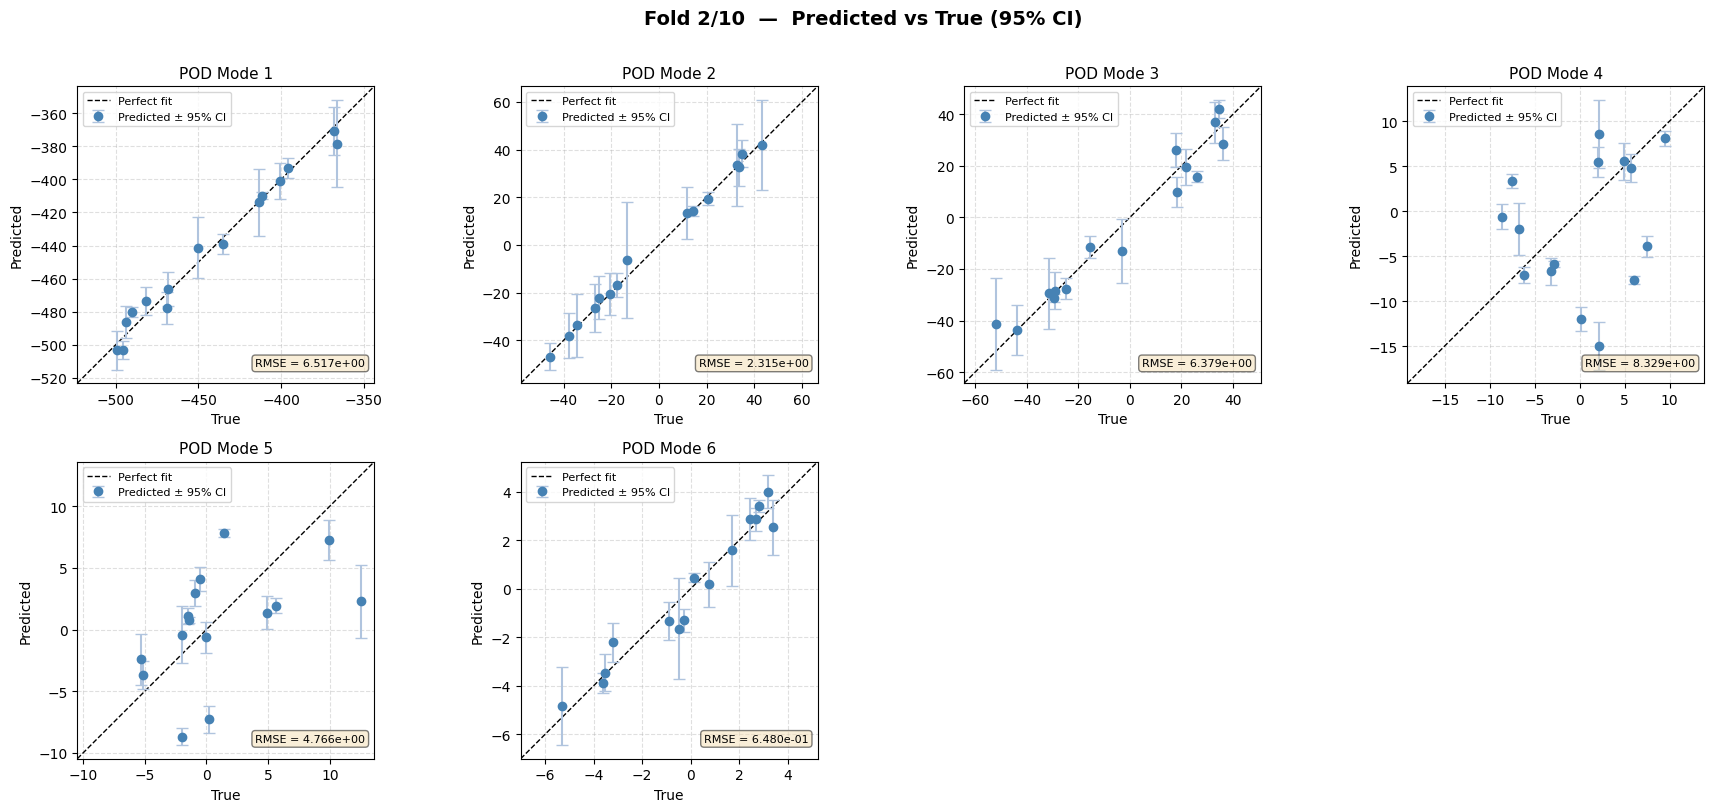

  Saved plot for fold 2


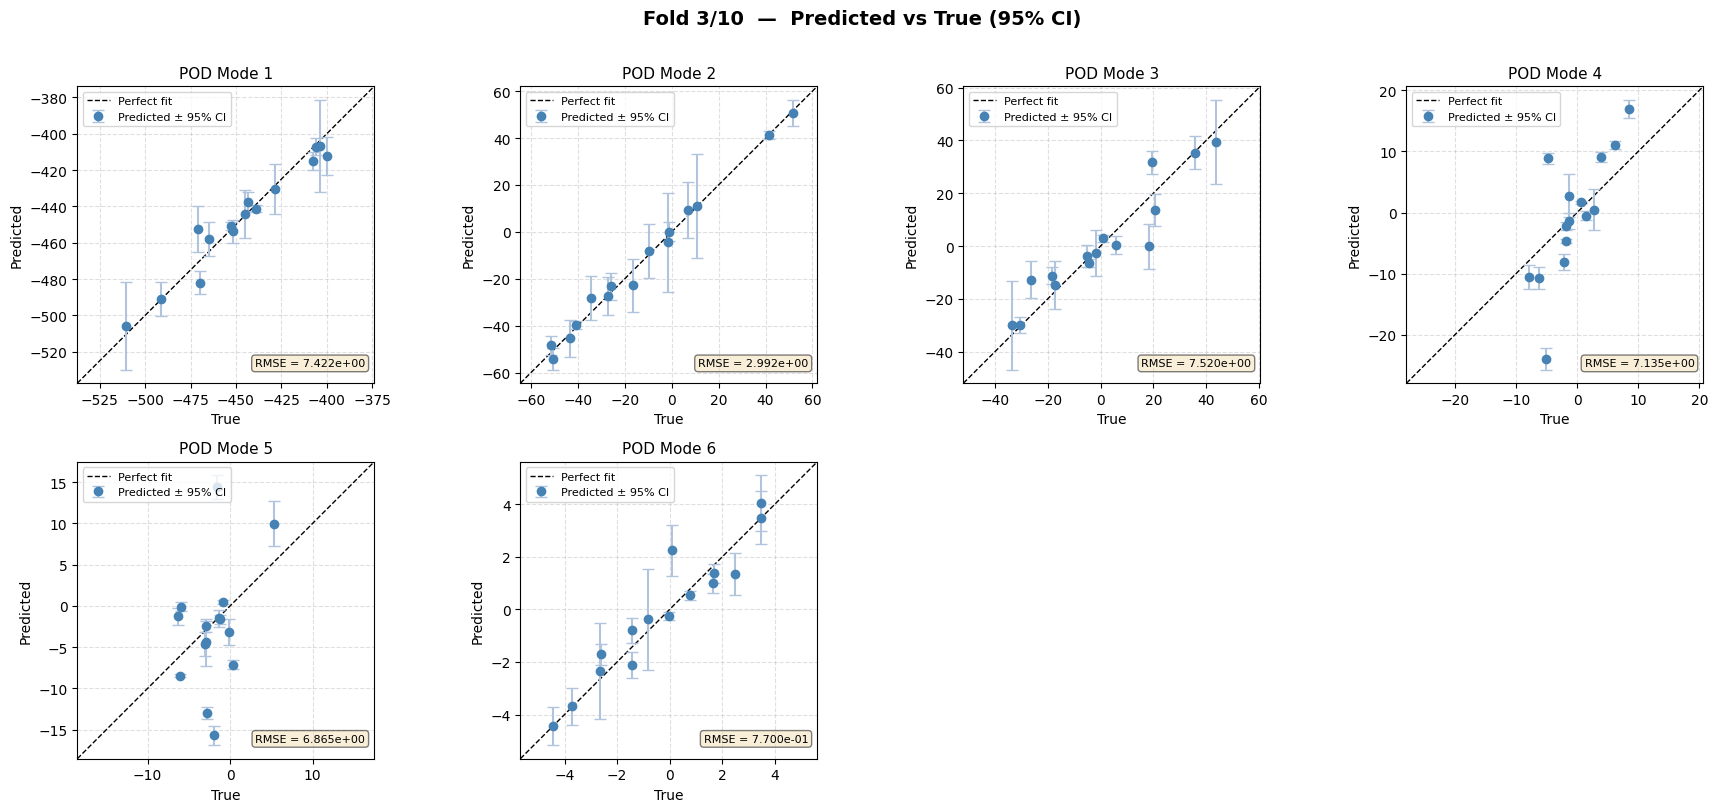

  Saved plot for fold 3


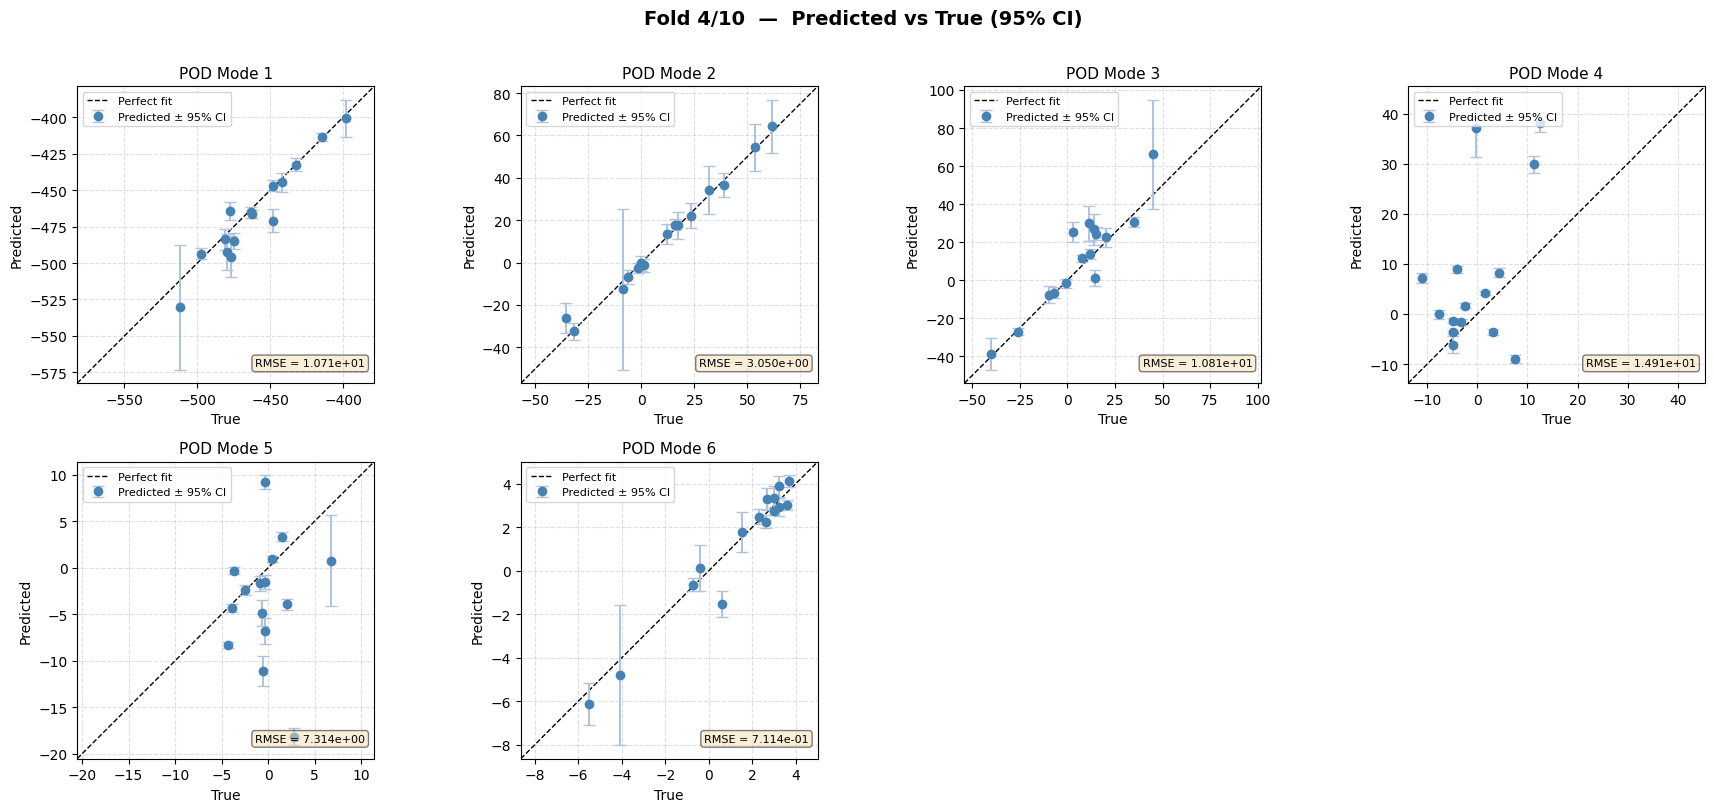

  Saved plot for fold 4


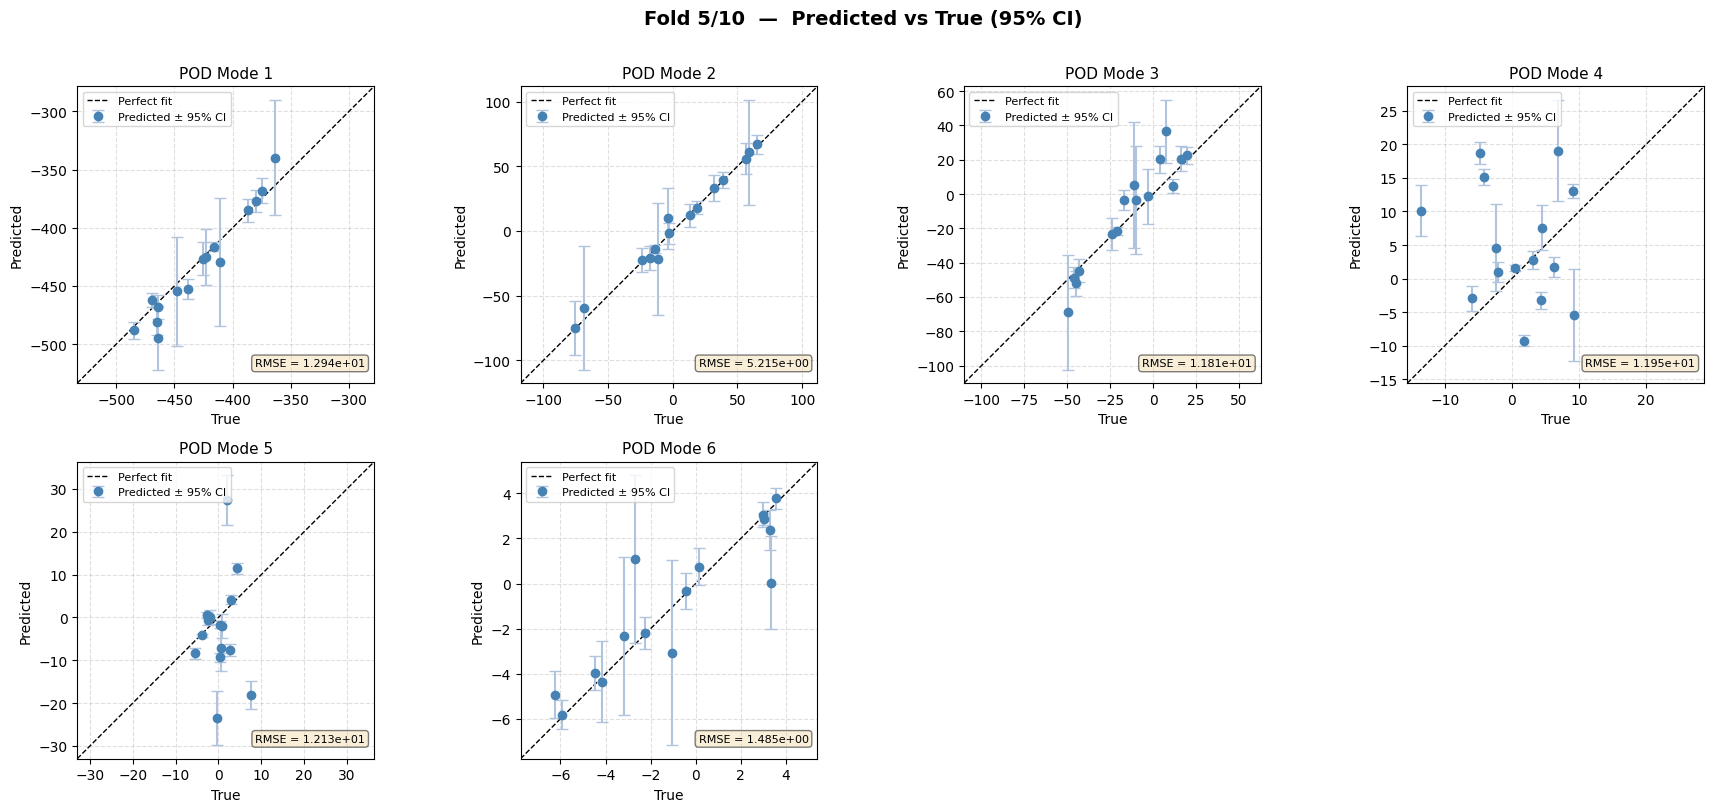

  Saved plot for fold 5


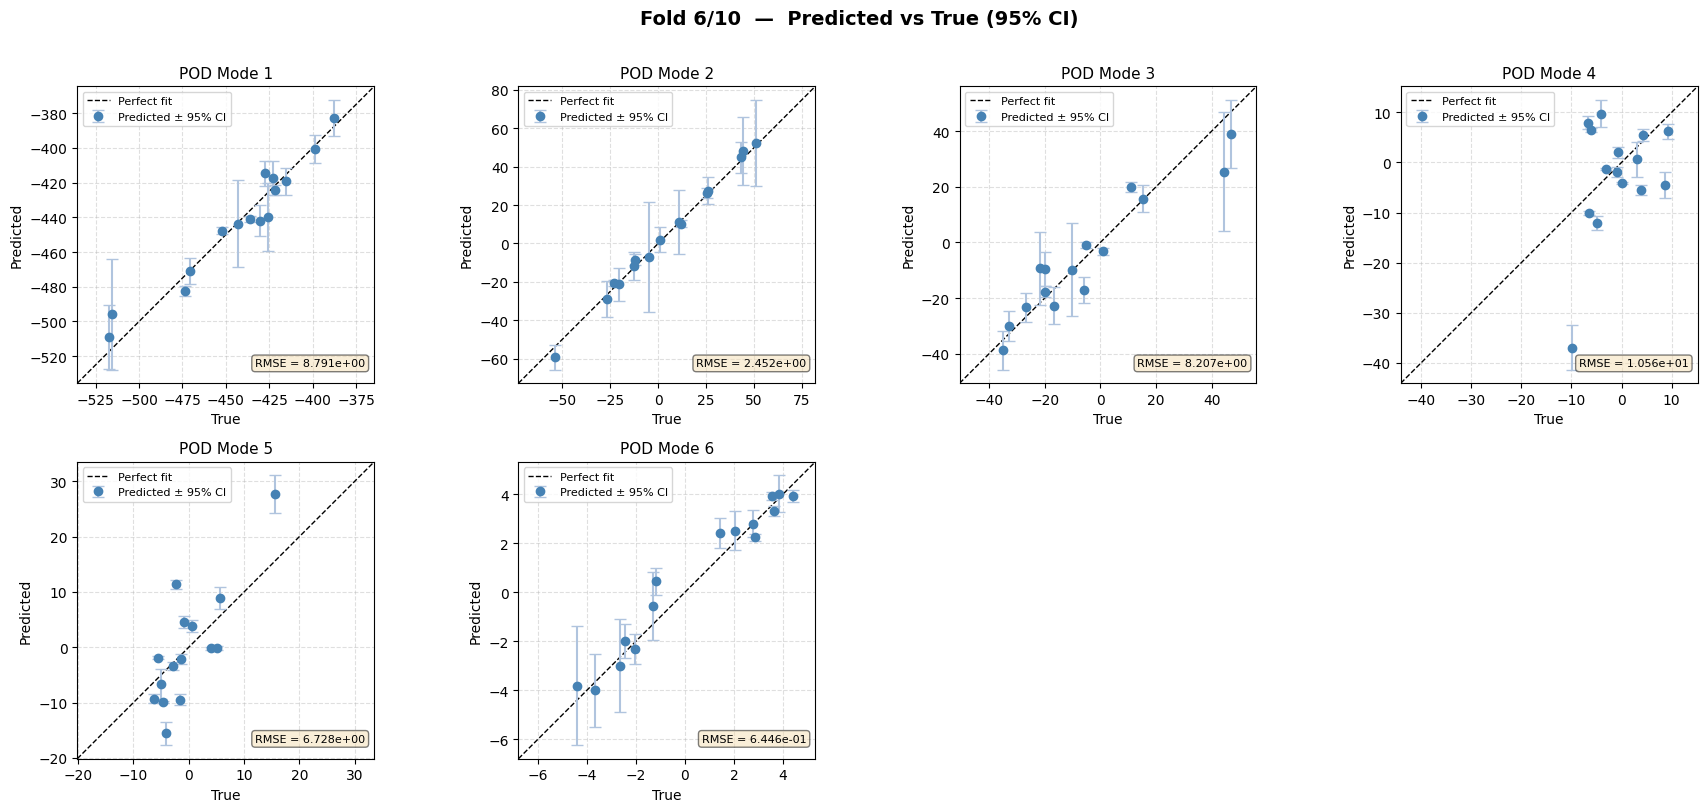

  Saved plot for fold 6


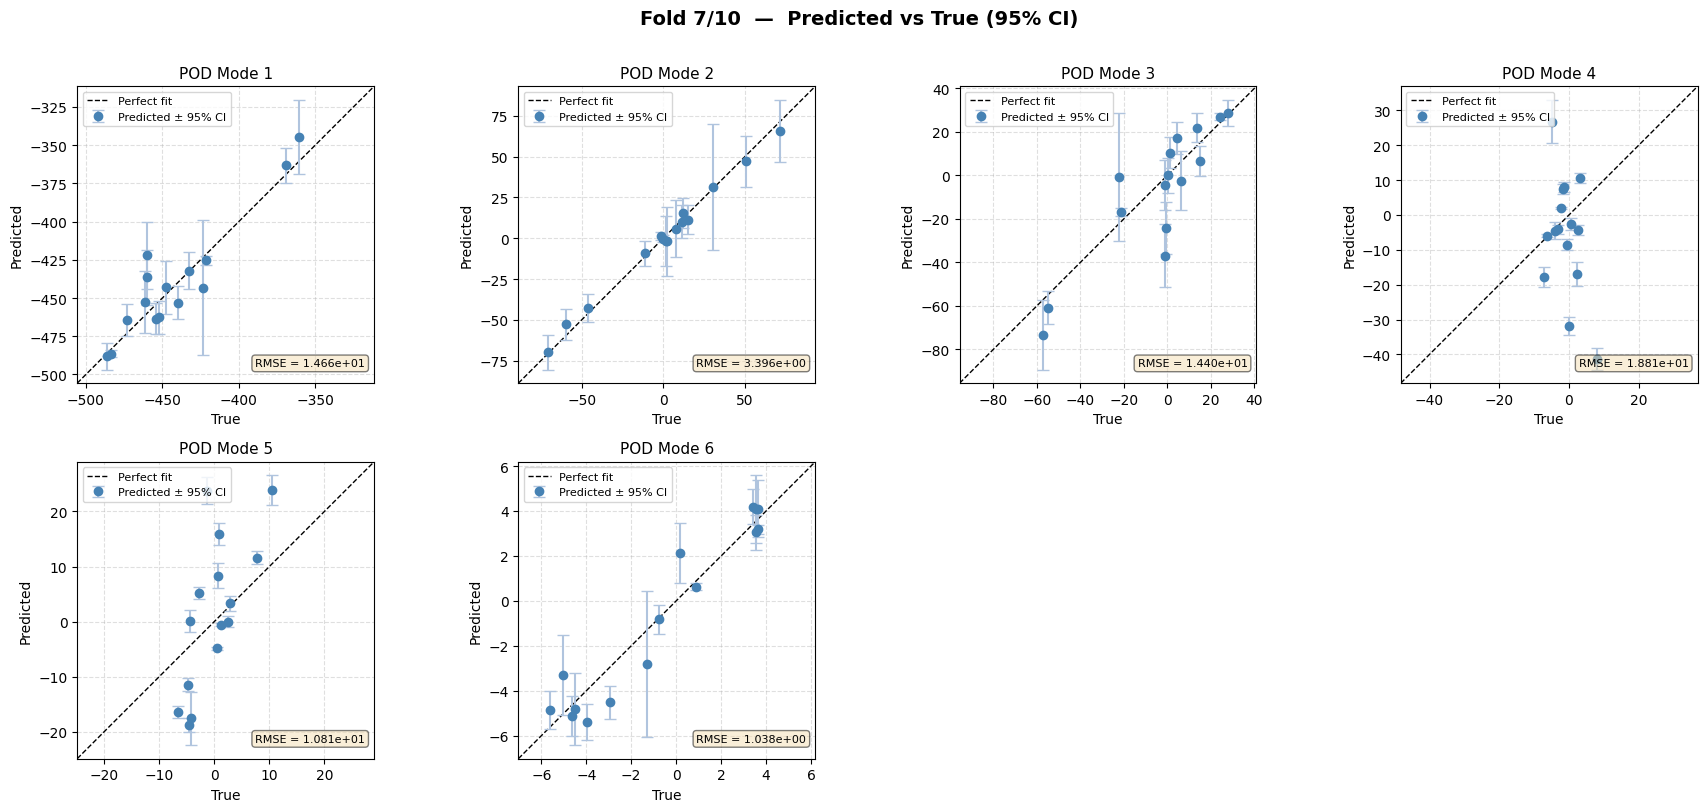

  Saved plot for fold 7


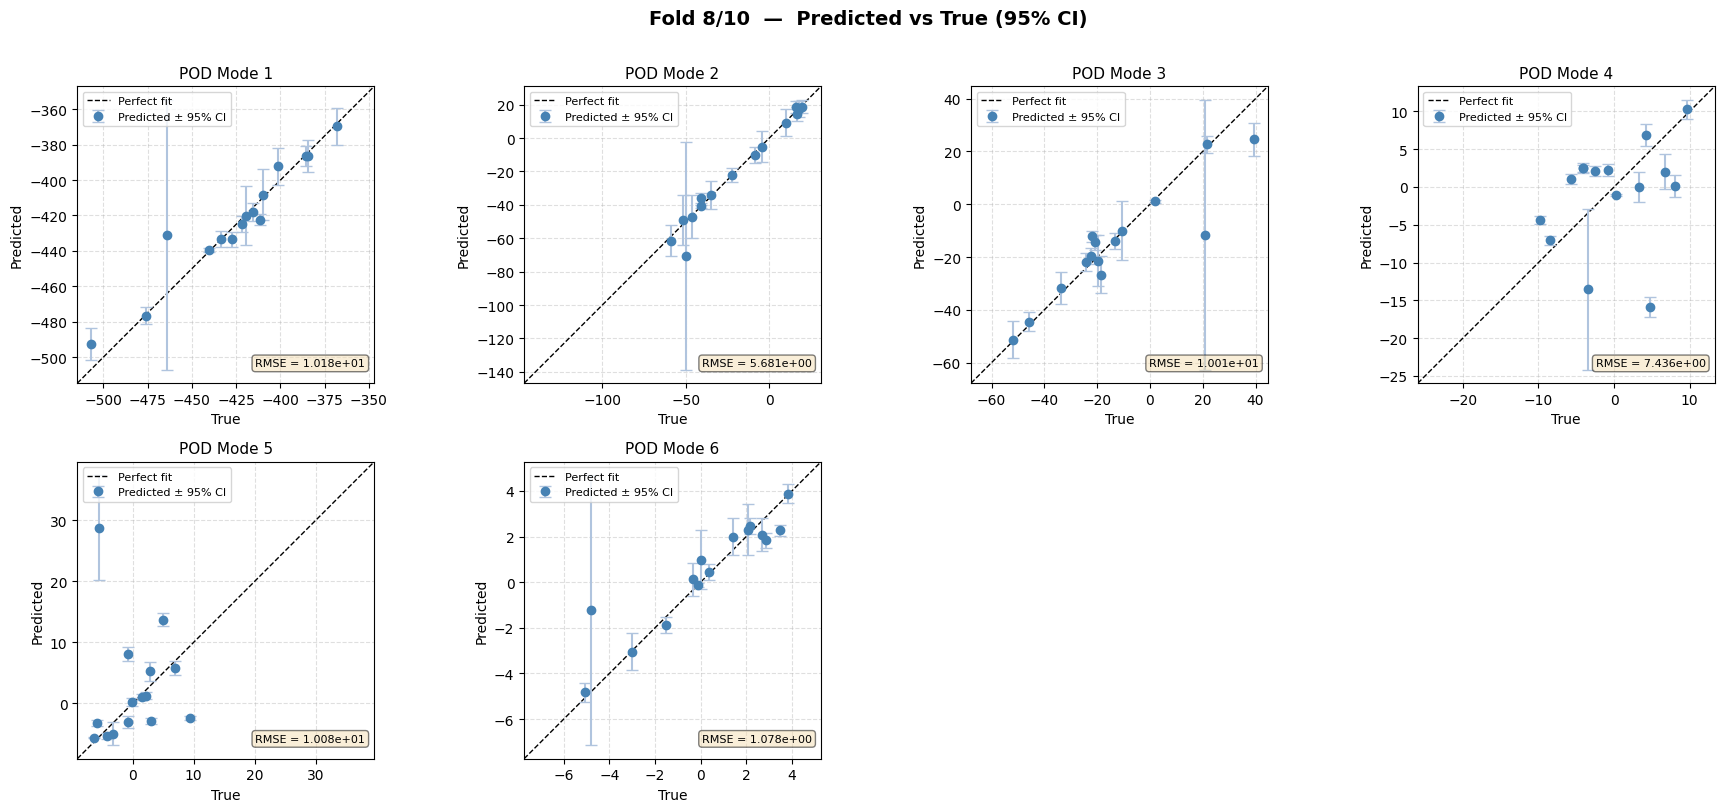

  Saved plot for fold 8


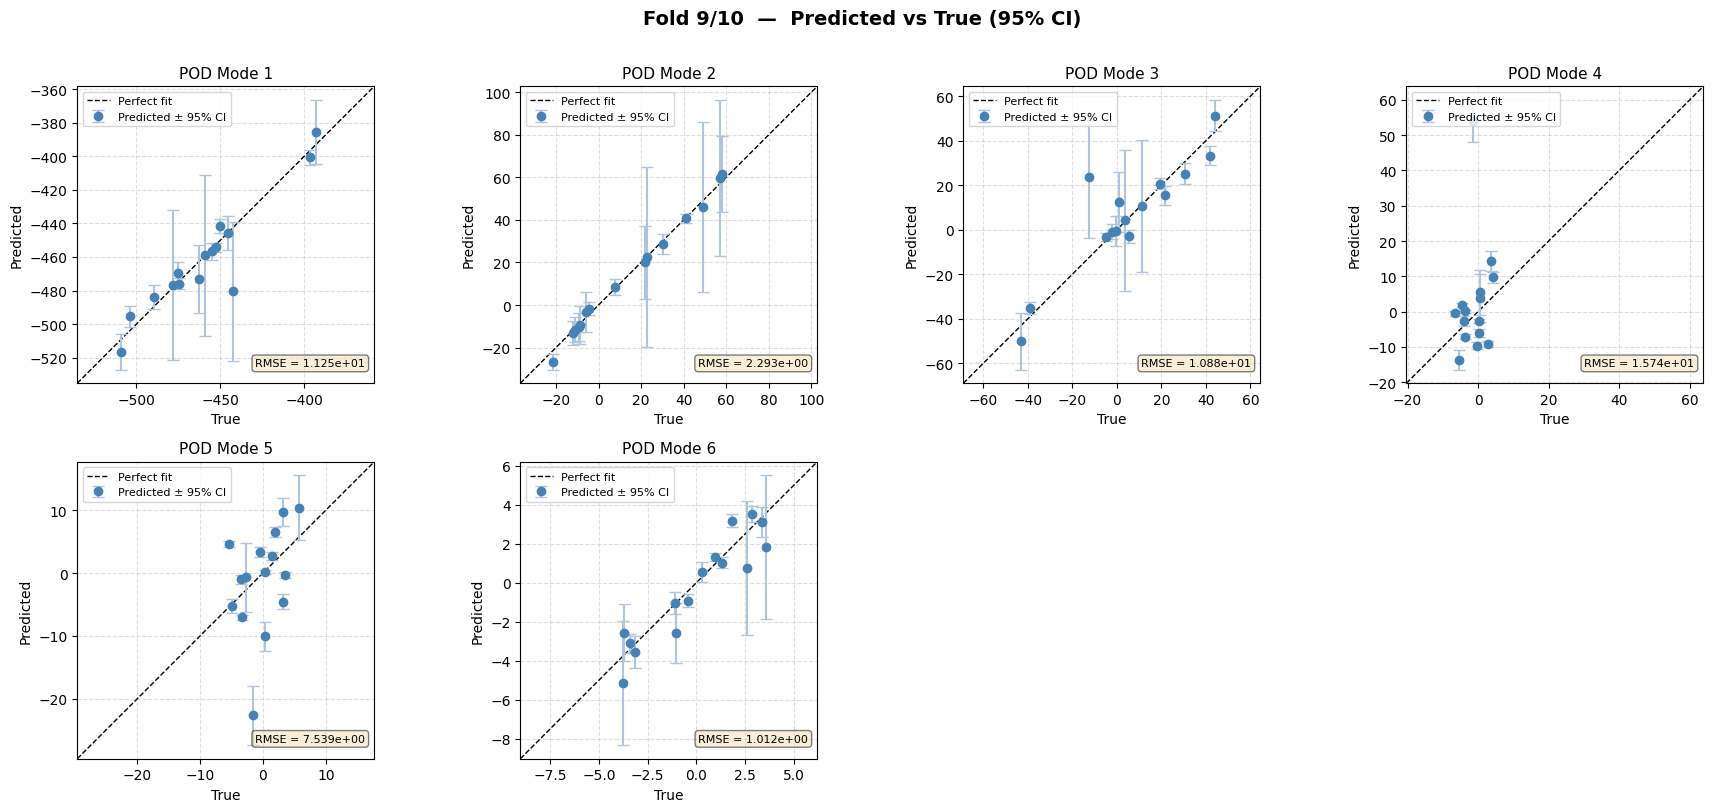

  Saved plot for fold 9


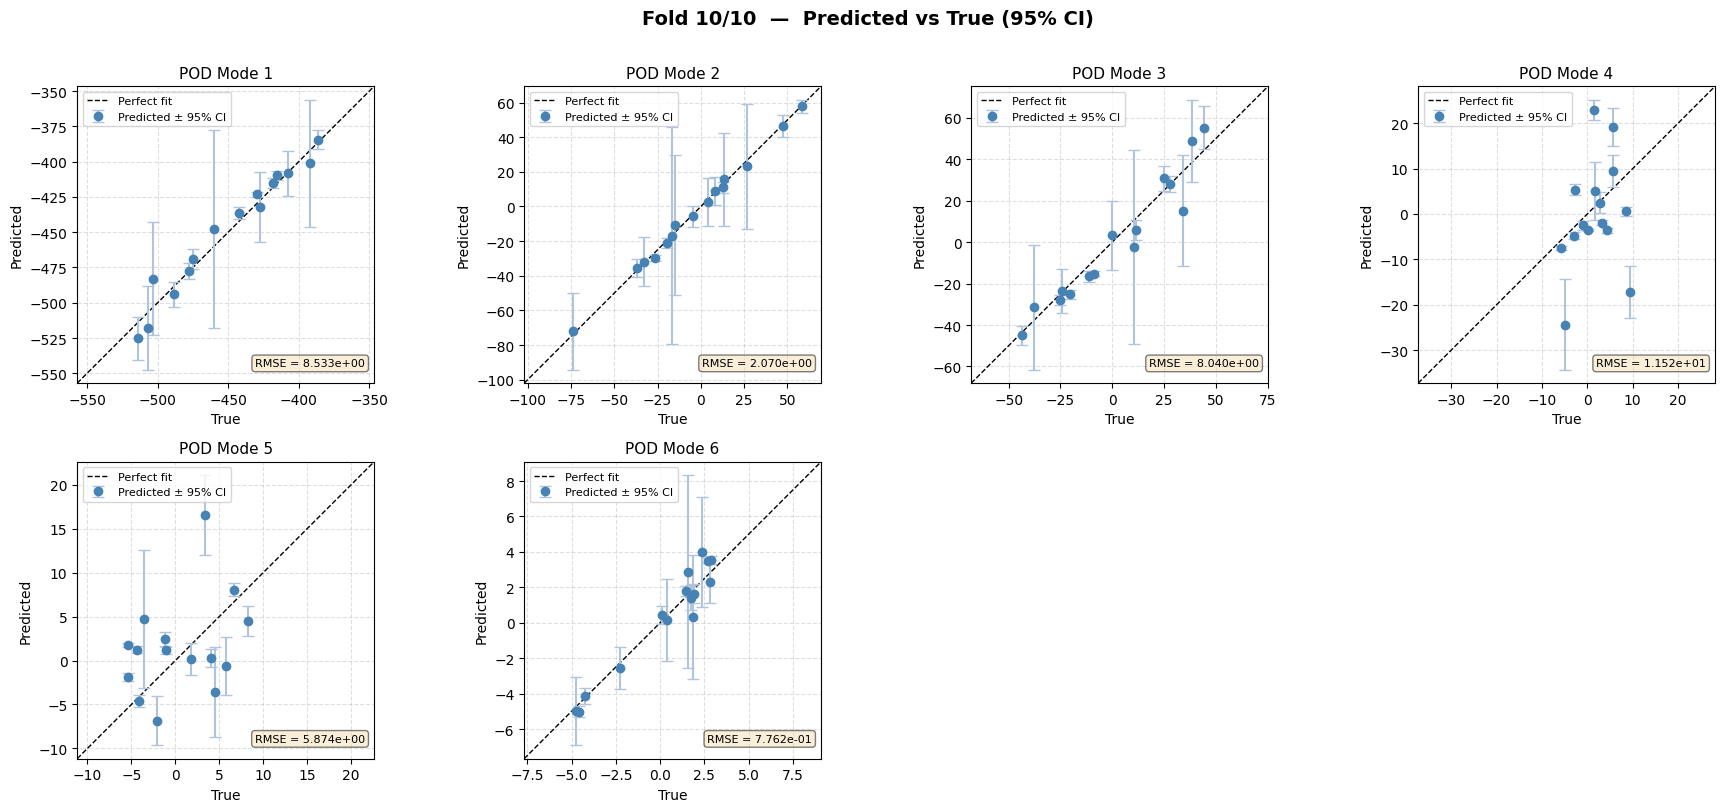

  Saved plot for fold 10


In [23]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 10-Fold CV (stores fold info for plotting) ────────────────────────────────
K         = 10
n_samples = X_train_norm.shape[0]
n_modes   = Y_train_norm.shape[1]

kf = KFold(n_splits=K, shuffle=True, random_state=42)

cv_preds_norm  = np.zeros_like(Y_train_norm)
cv_preds_phys  = np.zeros_like(Y_train_norm)
cv_vars_phys   = np.zeros_like(Y_train_norm)   # variance in physical space
cv_vars_norm   = np.zeros_like(Y_train_norm)
cv_fold_ids    = np.zeros(n_samples, dtype=int) # which fold each sample is test in

Y_true_phys = np.zeros_like(Y_train_norm)
for j in range(n_modes):
    Y_true_phys[:, j] = scalers_Y[j].inverse_transform(
        Y_train_norm[:, j].reshape(-1, 1)).ravel()

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_train_norm)):
    cv_fold_ids[test_idx] = fold_idx

    # Re-normalise inputs
    scaler_X_fold = StandardScaler()
    X_phys_train  = scaler_X.inverse_transform(X_train_norm[train_idx])
    X_phys_test   = scaler_X.inverse_transform(X_train_norm[test_idx])
    X_fold_train  = scaler_X_fold.fit_transform(X_phys_train)
    X_fold_test   = scaler_X_fold.transform(X_phys_test)

    # Re-normalise POD coefficients
    Y_fold_train   = np.zeros((len(train_idx), n_modes))
    scalers_Y_fold = []
    for j in range(n_modes):
        sc     = StandardScaler()
        Y_phys = scalers_Y[j].inverse_transform(
                     Y_train_norm[train_idx, j].reshape(-1, 1))
        Y_fold_train[:, j] = sc.fit_transform(Y_phys).ravel()
        scalers_Y_fold.append(sc)

    # Fit & predict
    for j in range(n_modes):
        model_fold = gstools.krige.Universal(
            gstools.Gaussian(dim=n_dims, var=1),
            cond_pos=X_fold_train.T,
            cond_val=Y_fold_train[:, j],
            drift_functions=list(expansion),
        )
        pred_norm, var_norm = model_fold(X_fold_test.T)

        cv_preds_norm[test_idx, j] = pred_norm
        cv_vars_norm [test_idx, j] = var_norm

        # Back-transform to physical space
        # For StandardScaler: y_phys = scale_ * y_norm + mean_
        # so std_phys = scale_ * sqrt(var_norm)
        scale = scalers_Y_fold[j].scale_[0]
        cv_preds_phys[test_idx, j] = scalers_Y_fold[j].inverse_transform(
            pred_norm.reshape(-1, 1)).ravel()
        cv_vars_phys[test_idx, j]  = var_norm * scale**2   # variance in phys space

    print(f"  Fold {fold_idx+1}/{K} complete  "
          f"(train={len(train_idx)}, test={len(test_idx)})")

# ── Predicted vs True plots — one figure per fold ────────────────────────────
ncols  = min(n_modes, 4)
nrows  = int(np.ceil(n_modes / ncols))
z95    = 1.96   # 95% CI multiplier

for fold_idx in range(K):
    test_mask = cv_fold_ids == fold_idx

    y_true = Y_true_phys  [test_mask]   # (n_test, n_modes)
    y_pred = cv_preds_phys[test_mask]
    y_std  = np.sqrt(cv_vars_phys[test_mask])   # std in physical space

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 4 * nrows),
                             squeeze=False)
    fig.suptitle(f"Fold {fold_idx + 1}/{K}  —  Predicted vs True (95% CI)",
                 fontsize=14, fontweight='bold', y=1.01)

    for j, ax in enumerate(axes.flat):
        if j >= n_modes:
            ax.set_visible(False)
            continue

        t = y_true[:, j]
        p = y_pred[:, j]
        s = y_std [:, j] * z95

        # Diagonal (perfect prediction line)
        lo = min(t.min(), (p - s).min())
        hi = max(t.max(), (p + s).max())
        pad = (hi - lo) * 0.05
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
                'k--', lw=1, label='Perfect fit')

        # Error bars (95% CI on prediction)
        ax.errorbar(t, p, yerr=s,
                    fmt='o', color='steelblue', ecolor='lightsteelblue',
                    elinewidth=1.5, capsize=4, markersize=6,
                    label='Predicted ± 95% CI')

        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('True', fontsize=10)
        ax.set_ylabel('Predicted', fontsize=10)
        ax.set_title(f'POD Mode {j + 1}', fontsize=11)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.4)

        # Annotate RMSE on each subplot
        rmse = np.sqrt(np.mean((t - p)**2))
        ax.text(0.97, 0.05, f'RMSE = {rmse:.3e}',
                transform=ax.transAxes, fontsize=8,
                ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    fig.tight_layout()
    plt.savefig(os.path.join(OUTPUT_BASE, f'cv_fold_{fold_idx+1:02d}_pred_vs_true.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved plot for fold {fold_idx+1}")

---
# Stage 3: Probabilistic Flood Mapping
## Steps 7–9: Sample → Predict → Aggregate

We generate a large Monte Carlo ensemble of inflow combinations at the target return period, pass them through the trained surrogate, and aggregate to produce probabilistic flood maps.

In [31]:
# Load trained surrogate from disk if not already in memory
try:
    _ = pck_models
    print("Using in-memory surrogate.")
except NameError:
    print("Loading surrogate from disk...")
    surrogate = joblib.load(os.path.join(OUTPUT_BASE, 'trained_surrogate.joblib'))
    pck_models    = surrogate['pck_models']
    scaler_X      = surrogate['scaler_X']
    scalers_Y     = surrogate['scalers_Y']
    U             = surrogate['U']
    N_POD_MODES   = surrogate['N_POD_MODES']
    NROWS         = surrogate['NROWS']
    NCOLS         = surrogate['NCOLS']
    X_train_norm  = surrogate['X_train_norm']
    print("surrogate loaded.")

Using in-memory surrogate.


In [32]:
# Step 7: Generate large Monte Carlo ensemble
N_MC = 50  # adjust as needed

mc_samples = joint.sample(N_MC, rule='random', seed=42)
mc_inputs  = np.array(mc_samples)  # shape: (n_dims, N_MC)

# Save for reproducibility
pd.DataFrame(mc_inputs.T,
             columns=dist_labels).to_csv(
    os.path.join(SAMPLES_DIR, f"mc_samples_{RETURN_PERIOD}yr_{N_MC}.csv"), index=False)

print(f"Generated {N_MC} Monte Carlo samples across {n_dims} dimensions.")

Generated 50 Monte Carlo samples across 3 dimensions.


In [37]:
# Steps 8–9: Predict inundation maps and generate probabilistic outputs

z_95 = 1.645  # 5th/95th percentile factor
# os.makedirs(PREDICTIONS_DIR, exist_ok=True)

all_mean_maps = []

for i in tqdm(range(N_MC), desc="Predicting flood maps"):
    x_new = scaler_X.transform(mc_inputs[:, i].reshape(1, -1))

    coeffs, stds = [], []
    for model_idx, pck in enumerate(pck_models):
        pck(x_new.T)
        mean_unscaled = scalers_Y[model_idx].inverse_transform(
            pck.field.reshape(-1, 1)).ravel()
        std_unscaled  = scalers_Y[model_idx].scale_ * np.sqrt(pck.krige_var)
        coeffs.append(mean_unscaled)
        stds.append(std_unscaled)

    coeffs = np.array(coeffs).flatten()
    stds   = np.array(stds).flatten()

    flood_map       = (U[:, :N_POD_MODES] @ coeffs).reshape((NROWS, NCOLS))
    flood_std_map   = (U[:, :N_POD_MODES] @ stds).reshape((NROWS, NCOLS))
    flood_lower_map = np.maximum(flood_map - z_95 * flood_std_map, 0)
    flood_upper_map = flood_map + z_95 * flood_std_map

    all_mean_maps.append(np.maximum(flood_map, 0))

    # Save individual prediction
    np.savetxt(os.path.join(PREDICTIONS_DIR, f"predicted_{i+1}.csv"),       flood_map,       delimiter=",")
    np.savetxt(os.path.join(PREDICTIONS_DIR, f"predicted_{i+1}_5pct.csv"),  flood_lower_map, delimiter=",")
    np.savetxt(os.path.join(PREDICTIONS_DIR, f"predicted_{i+1}_95pct.csv"), flood_upper_map, delimiter=",")

    if (i + 1) % 100 == 0:
        print(f"  Predicted {i+1}/{N_MC}")

print("\nAll predictions complete.")

# ── Aggregate to probabilistic flood maps ──────────────────────────────────
all_mean_maps = np.array(all_mean_maps)  # (N_MC, NROWS, NCOLS)

depth_threshold = 0.1  # metres — cells above this are considered inundated

prob_inundation = np.mean(all_mean_maps > depth_threshold, axis=0)
depth_p50       = np.percentile(all_mean_maps, 50,  axis=0)
depth_p05       = np.percentile(all_mean_maps, 5,   axis=0)
depth_p95       = np.percentile(all_mean_maps, 95,  axis=0)

# Save aggregated maps
np.savetxt(os.path.join(PREDICTIONS_DIR, "prob_inundation.csv"),  prob_inundation, delimiter=",")
np.savetxt(os.path.join(PREDICTIONS_DIR, "depth_p50.csv"),         depth_p50,       delimiter=",")
np.savetxt(os.path.join(PREDICTIONS_DIR, "depth_p05.csv"),         depth_p05,       delimiter=",")
np.savetxt(os.path.join(PREDICTIONS_DIR, "depth_p95.csv"),         depth_p95,       delimiter=",")

print(f"Probabilistic maps saved to: {PREDICTIONS_DIR}")

Predicting flood maps: 100%|█████████████████| 50/50 [01:55<00:00,  2.31s/it]



All predictions complete.
Probabilistic maps saved to: ./Inverurie_outputs/predictions


In [ ]:
# Visualise probabilistic flood maps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

maps = [
    (prob_inundation, 'Probability of Inundation', 'YlOrRd', None),
    (depth_p50,       'Median Flood Depth (m)',     'Blues',  None),
    (depth_p05,       '5th Percentile Depth (m)',   'Blues',  None),
    (depth_p95,       '95th Percentile Depth (m)',  'Blues',  None),
]

for ax, (data, title, cmap, vmax) in zip(axes.flat, maps):
    im = ax.imshow(data, cmap=cmap, origin='upper', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(
    f"{SITE_NAME} — Probabilistic Flood Maps Using Surrogate  (1-in-{RETURN_PERIOD} year, N={N_MC})",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"probabilistic_flood_maps_{RETURN_PERIOD}yr.png"), dpi=150)
plt.show()
print("Figure saved.")

Using 50 matched pairs
True maps found:      953
Predicted maps found: 1000
Matched pairs:        50


Computing metrics: 100%|█████████████████████| 50/50 [01:21<00:00,  1.63s/it]


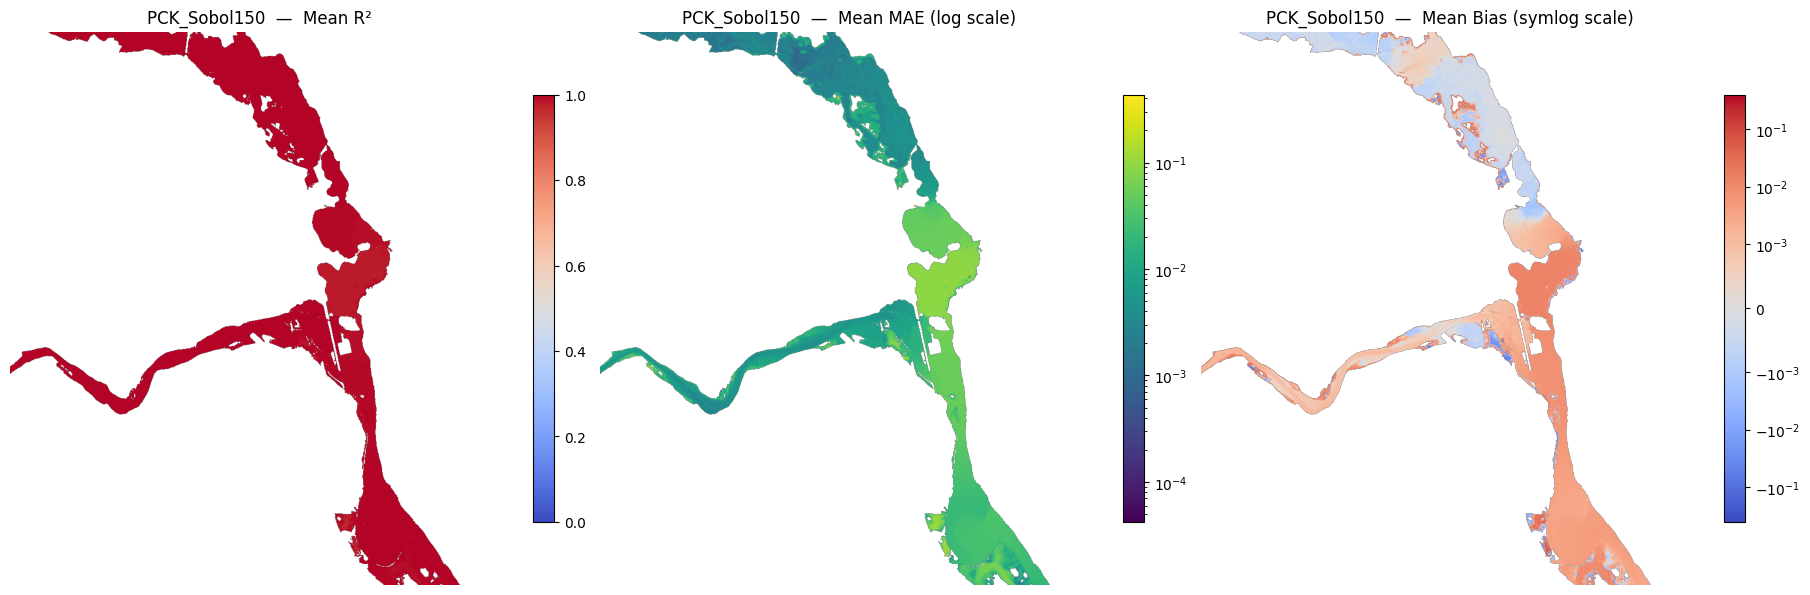

Figure saved to: ./Inverurie_outputs/figures\PCK_Sobol150_R2_MAE_Bias.png

=== PCK_Sobol150 PERFORMANCE SUMMARY (50 cases) ===
R²    mean=0.996   median=0.999
MAE   mean=0.026   median=0.016
Bias  mean=0.003   median=0.001

✅ Metrics saved to: ./Inverurie_outputs\PCK_Sobol150_metrics.npz


In [35]:
# now validation against Full MC
from matplotlib.colors import LogNorm, SymLogNorm
import re

# ── Paths ───────────────────────────────────────────────────────────────────
TRUE_MAPS_DIR = r"Z:\inverurie_data\max_maps_FMC"
PRED_MAPS_DIR = r"Z:\inverurie_data\predicted_PCK_Inver_csv_files_Sobol150"
method_name   = "PCK_Sobol150"

def extract_index(filename):
    """Extract the last number found in a filename."""
    numbers = re.findall(r'\d+', filename)
    return int(numbers[-1]) if numbers else None

# ── Match true .max files to predicted .csv files by index ──────────────────
true_files = {}
for f in os.listdir(TRUE_MAPS_DIR):
    if f.endswith(".max"):
        idx = extract_index(f)
        if idx is not None:
            true_files[idx] = os.path.join(TRUE_MAPS_DIR, f)
            
pred_files = {}
for f in os.listdir(PRED_MAPS_DIR):
    if f.endswith(".csv") and "perc" not in f:
        idx = extract_index(f)
        if idx is not None:
            pred_files[idx] = os.path.join(PRED_MAPS_DIR, f)

common_keys = sorted(set(true_files.keys()) & set(pred_files.keys()))[:50]
print(f"Using {len(common_keys)} matched pairs")
print(f"True maps found:      {len(true_files)}")
print(f"Predicted maps found: {len(pred_files)}")
print(f"Matched pairs:        {len(common_keys)}")

# ── Initialise metric accumulators ──────────────────────────────────────────
counts   = np.zeros((NROWS, NCOLS), dtype=np.int32)
R2_map   = np.zeros((NROWS, NCOLS), dtype=np.float64)
MAE_map  = np.zeros((NROWS, NCOLS), dtype=np.float64)
Bias_map = np.zeros((NROWS, NCOLS), dtype=np.float64)

# ── Process each matched case ────────────────────────────────────────────────
skipped = []
for k in tqdm(common_keys, desc="Computing metrics"):
    true_map = process_flood_file(true_files[k])
    if true_map is None:
        skipped.append(k)
        continue

    pred_map = np.loadtxt(pred_files[k], delimiter=',', dtype=np.float32)

    wet = true_map > 0
    counts[wet] += 1

    var_true = np.var(true_map[wet])
    if var_true > 0:
        R2_map[wet] += 1 - (pred_map[wet] - true_map[wet])**2 / var_true

    MAE_map[wet]  += np.abs(pred_map[wet] - true_map[wet])
    Bias_map[wet] += pred_map[wet] - true_map[wet]

if skipped:
    print(f"Skipped {len(skipped)} files: {skipped}")

# ── Average metrics over valid (ever-inundated) cells ───────────────────────
valid     = counts > 0
R2_mean   = np.full((NROWS, NCOLS), np.nan)
MAE_mean  = np.full((NROWS, NCOLS), np.nan)
Bias_mean = np.full((NROWS, NCOLS), np.nan)

R2_mean[valid]   = R2_map[valid]   / counts[valid]
MAE_mean[valid]  = MAE_map[valid]  / counts[valid]
Bias_mean[valid] = Bias_map[valid] / counts[valid]

# ── Colour normalisation ─────────────────────────────────────────────────────
mae_norm  = LogNorm(
    vmin=max(np.nanmin(MAE_mean[valid]), 1e-6),
    vmax=np.nanmax(MAE_mean[valid])
)
bias_abs  = np.nanmax(np.abs(Bias_mean[valid]))
bias_norm = SymLogNorm(linthresh=0.001, vmin=-bias_abs, vmax=bias_abs)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im1 = axes[0].imshow(R2_mean,   cmap="coolwarm", vmin=0, vmax=1)
im2 = axes[1].imshow(MAE_mean,  cmap="viridis",  norm=mae_norm)
im3 = axes[2].imshow(Bias_mean, cmap="coolwarm", norm=bias_norm)

axes[0].set_title(f"{method_name}  —  Mean R²")
axes[1].set_title(f"{method_name}  —  Mean MAE (log scale)")
axes[2].set_title(f"{method_name}  —  Mean Bias (symlog scale)")

for ax, im in zip(axes, [im1, im2, im3]):
    ax.axis('off')
    fig.colorbar(im, ax=ax, shrink=0.75)

fig_path = os.path.join(FIGURES_DIR, f"{method_name}_R2_MAE_Bias.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {fig_path}")

# ── Global summary ───────────────────────────────────────────────────────────
print(f"\n=== {method_name} PERFORMANCE SUMMARY ({len(common_keys)} cases) ===")
print(f"R²    mean={np.nanmean(R2_mean):.3f}   median={np.nanmedian(R2_mean):.3f}")
print(f"MAE   mean={np.nanmean(MAE_mean):.3f}   median={np.nanmedian(MAE_mean):.3f}")
print(f"Bias  mean={np.nanmean(Bias_mean):.3f}   median={np.nanmedian(Bias_mean):.3f}")

# ── Save metric arrays ───────────────────────────────────────────────────────
npz_path = os.path.join(OUTPUT_BASE, f"{method_name}_metrics.npz")
np.savez(npz_path, R2_mean=R2_mean, MAE_mean=MAE_mean,
         Bias_mean=Bias_mean, counts=counts)
print(f"\n✅ Metrics saved to: {npz_path}")

## Appendix: prepare for html

In [38]:
import os
import numpy as np


# =========================================
# PARAMETERS
# =========================================
method_name   = "PCK"
max_cases     = 10
N_SAMPLES     = 50 # samples per cell for the emulation
PERCENTILES   = [2.5, 50, 97.5]
GAUSSIAN_Z    = 1.96
WET_THRESH    = 0.01 

# helper function
def build_file_dict(directory, prefix, suffix, excludes=(), strip=""):
    """
    Scan directory for files matching prefix/suffix, return {sim_id: filepath}.
    excludes: substrings that must NOT appear in filename.
    strip:    substring to remove from filename before extracting the integer ID.
    """
    matched = sorted([
        f for f in os.listdir(directory)
        if f.startswith(prefix) and f.endswith(suffix)
        and all(x not in f for x in excludes)
    ])
    result = {}
    for f in matched:
        name = f[len(prefix):]
        name = name.replace(strip, "")
        name = name.replace(suffix, "")
        name = name.strip("_")
        try:
            sim_id = int(name.split("_")[-1])
            result[sim_id] = os.path.join(directory, f)
        except ValueError:
            print(f"  Warning: could not parse ID from '{f}', skipping.")
    return result

# =========================================
# FILE MATCHING
# =========================================
true_dict = build_file_dict(TRUE_MAPS_DIR, prefix="test_Res_MC_", suffix=".max")
pred_dict = build_file_dict(PRED_MAPS_DIR, prefix="predicted_Res_", suffix=".csv",
                             excludes=["lower", "upper", "5perc", "95perc", "std"])
p5_dict   = build_file_dict(PRED_MAPS_DIR, prefix="predicted_Res_", suffix=".csv",
                             excludes=["95perc", "std"], strip="_5perc")
p95_dict  = build_file_dict(PRED_MAPS_DIR, prefix="predicted_Res_", suffix=".csv",
                             excludes=["5perc", "std"],  strip="_95perc")

common_keys = sorted(set(true_dict) & set(pred_dict) & set(p5_dict) & set(p95_dict))[:max_cases]
n_cases     = len(common_keys)
print(f"Found {n_cases} common test cases.")

for k in common_keys[:3]:
    print(f"  ID {k}: true={os.path.basename(true_dict[k])} | "
          f"mean={os.path.basename(pred_dict[k])} | "
          f"p5={os.path.basename(p5_dict[k])} | "
          f"p95={os.path.basename(p95_dict[k])}")


# =========================================
# ACCUMULATORS
# Instead of storing all realisations, we accumulate per-case percentiles
# and average them across cases at the end.
#
# pred_pct_acc : running sum of per-case percentile maps  (3, NROWS, NCOLS)
# true_all     : all true maps stacked                    (n_cases, NROWS, NCOLS)
#                (only 64 MB at float16 — fine to keep)
# =========================================
n_pcts       = len(PERCENTILES)
pred_pct_acc = np.zeros((n_pcts, NROWS, NCOLS), dtype=np.float64)
true_all     = np.zeros((n_cases, NROWS, NCOLS), dtype=np.float16)
valid_counts = np.zeros(n_cases, dtype=bool)   # track which cases loaded OK

# wet frequency accumulators
true_wet_acc = np.zeros(NROWS * NCOLS, dtype=np.int16)   # count of MC runs wet
pred_wet_acc = np.zeros(NROWS * NCOLS, dtype=np.int32)   # count of samples wet

rng = np.random.default_rng(seed=42)

# =========================================
# INCREMENTAL PROCESSING — one case at a time
# Peak memory per iteration: (N_SAMPLES, NROWS, NCOLS) float32
#   = 50 × 895 × 356 × 4 bytes ≈ 64 MB
# =========================================
for idx, k in enumerate(common_keys):
    print(f"Processing case {idx+1}/{n_cases} (ID={k})")

    # --- True map ---
    true_map = process_flood_file(true_dict[k])
    if true_map is None:
        print(f"  Skipping: unreadable true map.")
        continue
    true_all[idx]     = true_map.astype(np.float16)
    valid_counts[idx] = True

    # accumulate true wet count (one vote per MC run)
    true_wet_acc += (true_map.flatten() > WET_THRESH).astype(np.int16)

    # --- Emulator outputs ---
    pred_mean = np.loadtxt(pred_dict[k], delimiter=',', dtype=np.float32)
    pred_p5   = np.loadtxt(p5_dict[k],   delimiter=',', dtype=np.float32)
    pred_p95  = np.loadtxt(p95_dict[k],  delimiter=',', dtype=np.float32)

    # Derive std: σ = (p95 - p5) / (2 × z)
    pred_std  = np.clip((pred_p95 - pred_p5) / (2 * GAUSSIAN_Z), 0, None)

    # --- Zero-variance mask ---
    zero_var = (pred_std == 0)

    # --- Sample block: initialise with mean (correct for zero-var cells) ---
    # Shape: (N_SAMPLES, NROWS, NCOLS)
    samples = np.tile(pred_mean, (N_SAMPLES, 1, 1))

    # Draw only where std > 0
    if np.any(~zero_var):
        drawn = rng.normal(
            loc=pred_mean[~zero_var],
            scale=pred_std[~zero_var],
            size=(N_SAMPLES, int(np.sum(~zero_var)))
        )
        samples[:, ~zero_var] = np.clip(drawn, 0, None)

    # accumulate pred wet count (N_SAMPLES votes per case)
    pred_wet_acc += (samples > WET_THRESH).sum(axis=0).reshape(-1).astype(np.int32)

    # --- Compute percentiles over the N_SAMPLES axis for this case ---
    # Shape: (n_pcts, NROWS, NCOLS)
    case_pcts = np.percentile(samples, PERCENTILES, axis=0)

    # Accumulate into running sum
    pred_pct_acc += case_pcts

    n_zero = zero_var.sum()
    # print(f"  Zero-variance cells: {n_zero}/{NROWS*NCOLS} " f"({100*n_zero/(NROWS*NCOLS):.1f}%)")

    # Free the sample block immediately
    del samples, case_pcts

# =========================================
# FINALISE PERCENTILE MAPS
# =========================================
n_valid = valid_counts.sum()
print(f"\n{n_valid}/{n_cases} cases loaded successfully.")

# Average accumulated percentiles over valid cases
pred_pcts = pred_pct_acc / n_valid   # (n_pcts, NROWS, NCOLS)

# True percentiles: over the stacked MC runs (only valid cases)
true_valid = true_all[valid_counts].astype(np.float32)
true_pcts  = np.percentile(true_valid, PERCENTILES, axis=0)   # (n_pcts, NROWS, NCOLS)

# Mask permanently dry cells (true 95th pct == 0)
ever_wet = true_pcts[PERCENTILES.index(97.5)] > 0
for p_idx in range(n_pcts):
    true_pcts[p_idx][~ever_wet] = np.nan
    pred_pcts[p_idx][~ever_wet] = np.nan

print(f"Ever-wet cells: {ever_wet.sum()}/{NROWS*NCOLS} "
      f"({100*ever_wet.sum()/(NROWS*NCOLS):.1f}%)")

# =========================================
# LOAD DETERMINISTIC WET/DRY OUTLINE
# =========================================
det_path = "Z:/inverurie_data/max_maps_FMC/test_Res_MC_1.max"
det_map = process_flood_file(det_path)
det_wet = (det_map > 0).astype(np.float32)
det_wet[~ever_wet] = np.nan

# =========================================
# FIGURE 1 — True vs Predicted vs Difference percentile depth maps
# =========================================
fig, axes = plt.subplots(n_pcts, 3,
                          figsize=(18, 5 * n_pcts),
                          constrained_layout=True)

for p_idx, pct in enumerate(PERCENTILES):
    t    = true_pcts[p_idx]
    p    = pred_pcts[p_idx]
    diff = p - t
    vmax    = np.nanmax([np.nanmax(t), np.nanmax(p)])
    abs_max = np.nanmax(np.abs(diff))

    for col_idx, (ax, data) in enumerate(zip(axes[p_idx], [t, p, diff])):
        if col_idx < 2:
            cmap = plt.cm.Blues.copy()
            cmap.set_under('green')   # zeros → green
            vmin  = 1e-6              # anything below this → green
            vmax_ = vmax
            label = "Depth (m)"
        else:
            cmap  = "coolwarm"
            vmin  = -abs_max
            vmax_ = abs_max
            label = "Depth difference (m)"

        titles = [
            f"True — {pct}th percentile depth",
            f"{method_name} Predicted — {pct}th percentile depth",
            f"Pred − True — {pct}th percentile",
        ]
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax_)
        ax.set_title(titles[col_idx])
        ax.axis("off")
        fig.colorbar(im, ax=ax, shrink=0.75, label=label, extend='min' if col_idx < 2 else 'neither')
        ax.contour(det_wet, levels=[0.5], colors='black', linewidths=0.8, linestyles='--')

fig.suptitle(f"{method_name} — Probabilistic Flood Depth Percentiles "
             f"({n_valid} cases, {N_SAMPLES} samples/case for emulation at each cell)", fontsize=14)
det_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=0.8,
                         label='Deterministic wet/dry boundary')
fig.legend(handles=[det_line], loc='lower center', ncol=1, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
out1 = os.path.join(FIGURES_DIR, f"{method_name}_percentile_maps.png")
plt.savefig(f"{method_name}_percentile_maps.png", dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {out1}")

# =========================================
# SAVE
# =========================================
np.savez(f"{method_name}_probabilistic_maps.npz",
         true_pcts=true_pcts,
         pred_pcts=pred_pcts,
         percentiles=np.array(PERCENTILES),
         ever_wet=ever_wet)
print(f"Saved {method_name}_probabilistic_maps.npz")
print(f"\n Done — {method_name}, {n_valid} cases, {N_SAMPLES} samples for emulation at each cell.")

Found 10 common test cases.
  ID 1: true=test_Res_MC_1.max | mean=predicted_Res_1.csv | p5=predicted_Res_1_5perc.csv | p95=predicted_Res_1.csv
  ID 2: true=test_Res_MC_2.max | mean=predicted_Res_2.csv | p5=predicted_Res_2_5perc.csv | p95=predicted_Res_2.csv
  ID 3: true=test_Res_MC_3.max | mean=predicted_Res_3.csv | p5=predicted_Res_3_5perc.csv | p95=predicted_Res_3.csv
Processing case 1/10 (ID=1)
Processing case 2/10 (ID=2)
Processing case 3/10 (ID=3)
Processing case 4/10 (ID=4)
Processing case 5/10 (ID=5)
Processing case 6/10 (ID=6)
Processing case 7/10 (ID=7)
Processing case 8/10 (ID=8)
Processing case 9/10 (ID=9)
Processing case 10/10 (ID=10)

10/10 cases loaded successfully.
Ever-wet cells: 107751/900000 (12.0%)
Saved: ./Inverurie_outputs/figures\PCK_percentile_maps.png
Saved PCK_probabilistic_maps.npz

 Done — PCK, 10 cases, 50 samples for emulation at each cell.


In [ ]:
# need to convert to json
# ── spatial info for JSON export ──────────────────────────────────────────────
xllcorner = 388775.678079999983311
yllcorner  = 809730.744399999966845
cellsize   = 5.0
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)
xur = xllcorner + NCOLS * cellsize
yur = yllcorner + NROWS * cellsize
lon_ll, lat_ll = transformer.transform(xllcorner, yllcorner)
lon_ur, lat_ur = transformer.transform(xur, yur)
print(f"WGS84 bounds: [{lat_ll:.6f}, {lon_ll:.6f}] → [{lat_ur:.6f}, {lon_ur:.6f}]")


In [ ]:
flat_wet      = ever_wet.flatten()
n_total_true  = int(n_valid)
n_total_pred  = int(n_valid * N_SAMPLES)

def to_list(arr):
    out, flat = [], arr.flatten()
    for i in range(len(flat)):
        if not flat_wet[i] or not np.isfinite(flat[i]):
            out.append(None)
        else:
            out.append(round(float(flat[i]), 3))
    return out

def freq_to_list(counts, n_total):
    """Wet frequency 0–1, None outside ever-wet domain."""
    out = []
    for i in range(len(counts)):
        if not flat_wet[i]:
            out.append(None)
        else:
            out.append(round(float(counts[i]) / n_total, 4))
    return out

def flat_to_list(arr):
    """Flat array to list, None outside ever-wet domain."""
    out, flat = [], arr.flatten()
    for i in range(len(flat)):
        if not flat_wet[i] or not np.isfinite(flat[i]):
            out.append(None)
        else:
            out.append(round(float(flat[i]), 3))
    return out

export = {
    "percentiles":    PERCENTILES,
    "nrows":          int(NROWS),
    "ncols":          int(NCOLS),
    "bounds":         [[lat_ll, lon_ll], [lat_ur, lon_ur]],
    "true":           [to_list(true_pcts[i]) for i in range(n_pcts)],
    "pred":           [to_list(pred_pcts[i]) for i in range(n_pcts)],
    "true_wet_freq":  freq_to_list(true_wet_acc, n_total_true),
    "pred_wet_freq":  freq_to_list(pred_wet_acc, n_total_pred),
    "wet_thresh":     WET_THRESH,
    "n_true_runs":    n_total_true,
    "n_pred_samples": n_total_pred,
    "det":            flat_to_list(det_map),
}

out_json = os.path.join(f"{method_name}_probabilistic_maps.json")
print("Writing JSON...")
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(export, f, allow_nan=False)
print(f"JSON → {out_json}  ({os.path.getsize(out_json)/1e6:.1f} MB)")
print(f"\nDone — {method_name}, {n_valid} cases, {N_SAMPLES} samples/case.")